# 01 Model Inspection

Dieses Notebook untersucht `EleutherAI/pythia-410m` mit Fokus auf Sentiment-Analyse.  
Die eigentliche Logik liegt in separaten Python-Dateien; das Notebook ruft diese Funktionen nur in einer gut lesbaren Reihenfolge auf.


## 1. Installation & Imports

In diesem Kapitel werden die Projektmodule geladen, der Pfad für das Notebook gesetzt und das verfügbare Gerät ausgewählt.


In [65]:
%load_ext autoreload
%autoreload 2

import sys
import importlib
from pathlib import Path
from IPython.display import Image, display

current_dir = Path.cwd()
if (current_dir / "assignement" / "utils" / "config.py").exists():
    utils_dir = current_dir / "assignement" / "utils"
elif (current_dir / "utils" / "config.py").exists():
    utils_dir = current_dir / "utils"
elif (current_dir / "config.py").exists():
    utils_dir = current_dir
else:
    raise FileNotFoundError("Could not find the assignment utils directory.")

if str(utils_dir) not in sys.path:
    sys.path.insert(0, str(utils_dir))

import config
import model_utils
import lexicon_utils
import plotting_utils
import sentiment_embeddings
import linear_probe
import sst2_analysis

for module in [
    config,
    model_utils,
    plotting_utils,
    lexicon_utils,
    sentiment_embeddings,
    linear_probe,
    sst2_analysis,
]:
    importlib.reload(module)

from model_utils import (
    analyze_parameters,
    load_model_and_tokenizer,
    print_architecture_overview,
    run_top_k_predictions,
    setup_environment,
)
from sentiment_embeddings import (
    run_positive_negative_comparison,
    run_token_embedding_visualization,
)
from linear_probe import run_logistic_regression_probe
from lexicon_utils import (
    filter_data_set,
    form_sentiment_challenge_prompts,
    import_data_set,
    run_sentiment_challenge_top_token_analysis,
)
from sst2_analysis import run_sst2_inspection

device = setup_environment()


def display_image(png_name):
    image_path = config.OUTPUT_PNG_DIR / png_name
    if not image_path.exists():
        raise FileNotFoundError(f"PNG image not found in output directory: {image_path}")
    display(Image(filename=str(image_path)))


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

  Kapitel 1: Installation & Imports
PyTorch-Version : 2.6.0+cu124
Gerät           : cpu


### Ergebnisinterpretation

Die Ausgabe zeigt, welche PyTorch-Version verwendet wird und ob das Modell auf CPU oder GPU läuft.  
Falls `cuda` angezeigt wird, können Modellinferenz und Embedding-Analysen deutlich schneller laufen. Bei `cpu` funktionieren die Analysen genauso, dauern aber länger.


## 2. Modell und Tokenizer laden

Hier werden der Tokenizer und das Sprachmodell geladen. Das Modell wird in den Evaluationsmodus gesetzt, damit keine Trainingsoperationen ausgeführt werden.


In [66]:
model, tokenizer = load_model_and_tokenizer(device)



  Kapitel 2: Modell und Tokenizer laden


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]


Modell-Architektur:
GPTNeoXForCausalLM(
  (gpt_neox): GPTNeoXModel(
    (embed_in): Embedding(50304, 1024)
    (emb_dropout): Dropout(p=0.0, inplace=False)
    (layers): ModuleList(
      (0-23): 24 x GPTNeoXLayer(
        (input_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (post_attention_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (post_attention_dropout): Dropout(p=0.0, inplace=False)
        (post_mlp_dropout): Dropout(p=0.0, inplace=False)
        (attention): GPTNeoXAttention(
          (query_key_value): Linear(in_features=1024, out_features=3072, bias=True)
          (dense): Linear(in_features=1024, out_features=1024, bias=True)
        )
        (mlp): GPTNeoXMLP(
          (dense_h_to_4h): Linear(in_features=1024, out_features=4096, bias=True)
          (dense_4h_to_h): Linear(in_features=4096, out_features=1024, bias=True)
          (act): GELUActivation()
        )
      )
    )
    (final_layer_norm): LayerNorm

## 3. Architekturübersicht

Dieses Kapitel zeigt zentrale Architekturwerte wie Hidden Size, Anzahl der Schichten, Attention-Köpfe und Vokabulargröße.


In [67]:
print_architecture_overview(model)



  Kapitel 3: Architekturübersicht

--- Architektur-Parameter ---
Modelltyp              : gpt_neox
Versteckte Größe       : 1024
Schichten              : 24
Attention-Köpfe        : 16
Kopfdimension          : 64
Vokabulargröße         : 50304
Max. Positionen        : 2048


### Ergebnisinterpretation

Das verwendete Modell basiert auf der GPT-NeoX-Architektur und gehört zur Klasse der Decoder-Only Transformer. Im Gegensatz zur ursprünglichen Transformer-Architektur von Vaswani et al. aus dem Paper Attention Is All You Need, die aus einem Encoder- und einem Decoder-Stack besteht, verwendet GPT-NeoX ausschließlich Decoder-Blöcke mit maskierter Self-Attention. Dadurch kann das Modell autoregressiv arbeiten und auf Basis aller vorherigen Tokens das nächste Token vorhersagen.

Das Modell besitzt eine Vokabulargröße von 50.304 Tokens, eine Hidden Size von 1024 Dimensionen, 24 Transformer-Schichten, 16 Attention-Köpfe und eine maximale Kontextlänge von 2048 Tokens. Jedes Eingabetoken wird zunächst in einen 1024-dimensionalen Embedding-Vektor projiziert. Die Embedding-Schicht bildet somit den Ausgangspunkt aller weiteren Berechnungen innerhalb des Modells.

Jede der 24 Transformer-Schichten enthält zwei Layer-Normalization-Operationen, die die Aktivierungen stabilisieren und eine effizientere Verarbeitung der Informationen ermöglichen. Der Attention-Mechanismus basiert auf Multi-Head Self-Attention mit 16 Köpfen. Für jeden Token werden Query-, Key- und Value-Repräsentationen erzeugt, wobei alle drei Projektionen gemeinsam berechnet werden. Die resultierende Dimension von 3072 entspricht der dreifachen Hidden Size und wird anschließend in die einzelnen Query-, Key- und Value-Vektoren aufgeteilt. Da die Hidden Size 1024 beträgt und 16 Attention-Köpfe verwendet werden, besitzt jeder Kopf eine Dimension von 64 Merkmalen. Nach der Berechnung der Attention-Ergebnisse werden diese wieder in den ursprünglichen 1024-dimensionalen Hidden-State-Raum projiziert.

Auf den Attention-Block folgt ein mehrschichtiges Feed-Forward-Netzwerk (MLP). Dabei wird die interne Repräsentation zunächst von 1024 auf 4096 Dimensionen erweitert. Diese Expansion erhöht die Modellkapazität und ermöglicht die Verarbeitung komplexerer Merkmalskombinationen. Zwischen den beiden linearen Projektionen wird die nichtlineare GELU-Aktivierungsfunktion eingesetzt, welche sich in modernen Transformer-Architekturen als Standard etabliert hat. Anschließend wird die Repräsentation wieder auf die ursprüngliche Hidden Size von 1024 Dimensionen reduziert.

Zur Kodierung von Positionsinformationen verwendet GPT-NeoX Rotary Positional Embeddings (RoPE). Im Gegensatz zu klassischen Positions-Embeddings werden Positionsinformationen nicht additiv zu den Token-Embeddings hinzugefügt, sondern direkt über Rotationen innerhalb der Query- und Key-Repräsentationen eingebracht. Dadurch können relative Positionen zwischen Tokens effizient berücksichtigt werden und die Generalisierung auf längere Sequenzen wird verbessert.

Nach der letzten Transformer-Schicht wird eine finale Layer-Normalisierung durchgeführt, bevor die Hidden States auf die Größe des Vokabulars projiziert werden. Das Ergebnis dieser Projektion sind 50.304 Logits, also ein Score für jedes mögliche Token des Vokabulars. Durch Anwendung der Softmax-Funktion werden diese Logits in Wahrscheinlichkeiten umgewandelt, aus denen anschließend das nächste vorhergesagte Token ausgewählt wird.



## 4. Parameter-Zählung

Hier wird gezählt, wie viele Parameter in Embedding, Unembedding, Attention und MLP liegen. Zusätzlich wird eine Grafik zur Parameterverteilung gespeichert.



  Kapitel 4: Parameter-Zählung
Total parameters: 405,334,016
Token Embedding Params:   51,511,296  (12.71%)
Token Unembedding Params: 51,511,296  (12.71%)

Embed_in  data_ptr:  2790432702720
Embed_out data_ptr:  2351469428992
Embedding and Unembedding weights are tied? False

First layer parameter breakdown:
  input_layernorm.weight                   1,024
  input_layernorm.bias                     1,024
  post_attention_layernorm.weight          1,024
  post_attention_layernorm.bias            1,024
  attention.query_key_value.weight         3,145,728
  attention.query_key_value.bias           3,072
  attention.dense.weight                   1,048,576
  attention.dense.bias                     1,024
  mlp.dense_h_to_4h.weight                 4,194,304
  mlp.dense_h_to_4h.bias                   4,096
  mlp.dense_4h_to_h.weight                 4,194,304
  mlp.dense_4h_to_h.bias                   1,024

Component                       Params    Share
------------------------------------

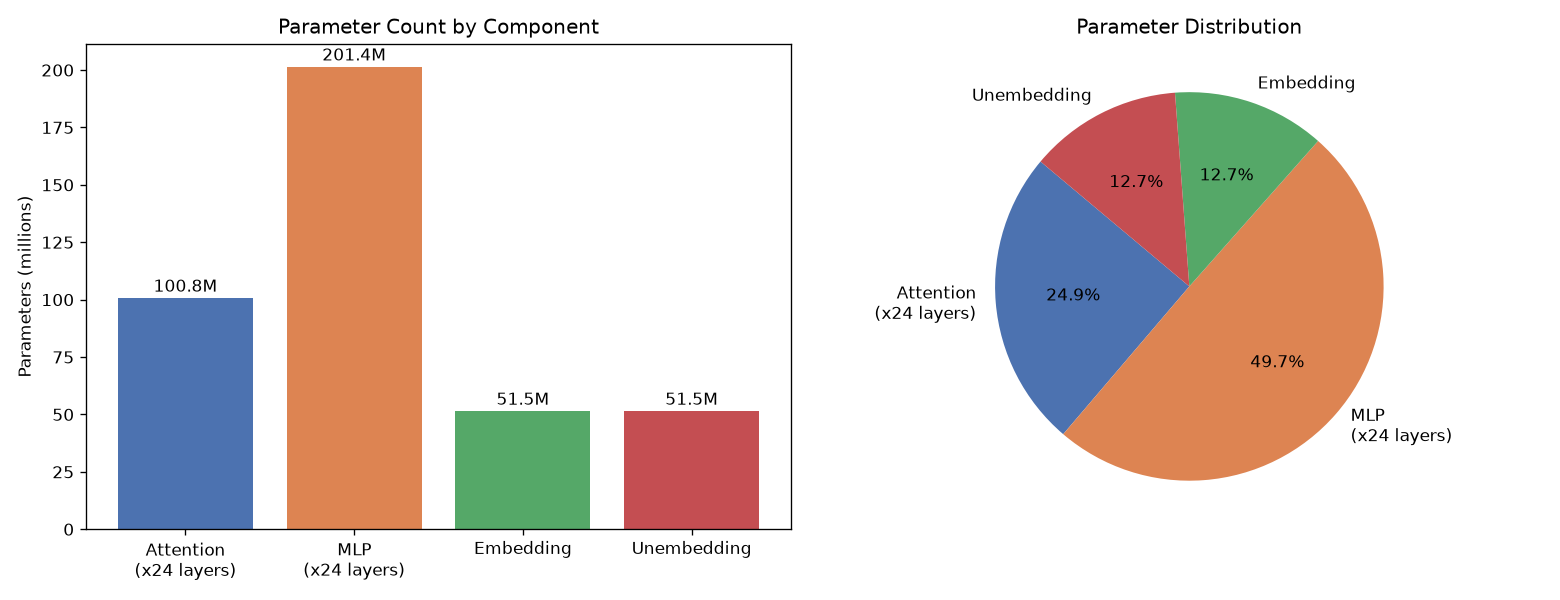

In [68]:
analyze_parameters(model)
display_image('parameterverteilung.png')

### Ergebnisinterpretation

Die Parameterzählung sind folgends verteilet:
- Embedding Matrix (50,304 × 1,024) = 51,511,296
- Transformer Layers (24 × 12,596,224) = 302,309,376
    - Transformer Layer (4,096 + 4,198,400 + 8,393,728) = 12,596,224
        - Input LayerNorm (1,024 + 1,024) = 2,048
        - Attention (3,148,800 + 1,049,600) = 4,198,400
            - QKV Projection ((1,024 × 3,072) + 3,072) = 3,148,800
            - Query/ Key Rotary Embedding = 0 (Pure Math)
            - Output Projection ((1,024 × 1,024) + 1,024) = 1,049,600
        - Post-Attention LayerNorm (1,024 + 1,024) = 2,048
    - MLP (4,198,400 + 4,195,328) = 8,393,728
        - Expansion ((1,024 × 4,096) + 4,096) = 4,198,400
        - Compression ((4,096 × 1,024) + 1,024) = 4,195,328
- Final LayerNorm (1,024 + 1,024) = 2,048
- Unembedding Matrix (1,024 × 50,304) = 51,511,296

Summe (51,511,296 + 302,309,376 + 2,048 + 51,511,296) = 405,334,016


Obwohl die Transformer-Architektur auf der bahnbrechenden Arbeit *Attention Is All You Need* von Vaswani et al. basiert, zeigt die Parameteranalyse dieses GPT-NeoX-Modells ein anderes Bild. Von insgesamt 12,6 Millionen Parametern pro Transformer-Layer entfallen lediglich etwa 4,2 Millionen (≈ 33 %) auf den Attention-Mechanismus, während rund 8,4 Millionen Parameter (≈ 67 %) im MLP-Block liegen. Betrachtet man die reine Parameterverteilung, könnte man daher scherzhaft sagen: **„Attention Is All You Need“ wird in der Praxis eher zu „Attention Is Only 25–33 % of What You Need“.** Der Großteil der Modellkapazität befindet sich nicht in der Attention selbst, sondern in den Feed-Forward-Netzwerken, die einen wesentlichen Beitrag zur Speicherung und Verarbeitung des im Modell enthaltenen Wissens leisten.


## 5. Top-K Vorhersagen

Für mehrere positive und negative Beispielprompts werden die wahrscheinlichsten nächsten Tokens ausgegeben. So sieht man, welche Fortsetzungen das Modell bevorzugt.


In [69]:
example_prompts = [
    "The food was delicious and the service was",
    "The food was disgusting and the service was",
    "I love this movie and I feel very",
    "I hate this movie and I feel very",
]

run_top_k_predictions(example_prompts, model, tokenizer, device)


  Kapitel 5: Top-K Vorhersagen

Prompt: The food was delicious and the service was
------------------------------------------------------------
1. Token: ' excellent'    | Token-ID:  7126 | Wahrscheinlichkeit: 0.1208
2. Token: ' very'         | Token-ID:  1077 | Wahrscheinlichkeit: 0.0802
3. Token: ' great'        | Token-ID:  1270 | Wahrscheinlichkeit: 0.0774
4. Token: ' impe'         | Token-ID: 19812 | Wahrscheinlichkeit: 0.0541
5. Token: ' good'         | Token-ID:  1175 | Wahrscheinlichkeit: 0.0498

Prompt: The food was disgusting and the service was
------------------------------------------------------------
1. Token: ' terrible'     | Token-ID: 11527 | Wahrscheinlichkeit: 0.0756
2. Token: ' awful'        | Token-ID: 18580 | Wahrscheinlichkeit: 0.0742
3. Token: ' poor'         | Token-ID:  4105 | Wahrscheinlichkeit: 0.0488
4. Token: ' horrible'     | Token-ID: 19201 | Wahrscheinlichkeit: 0.0483
5. Token: ' atroc'        | Token-ID: 36837 | Wahrscheinlichkeit: 0.0308

Prompt: I 

### Ergebnisinterpretation

Die Ergebnisse zeigen, dass das Modell in der Lage ist, den emotionalen Kontext eines Satzes zu erkennen und entsprechende Wortvorhersagen zu erzeugen. Bei positiv formulierten Eingaben wie "The food was delicious and the service was" dominieren positive Fortsetzungen wie excellent, great oder good. Im Gegensatz dazu erzeugt das Modell bei negativ formulierten Eingaben wie "The food was disgusting and the service was" überwiegend negative Fortsetzungen wie terrible, awful oder horrible.


## 6. Positiv vs. Negativ Vergleich

In diesem Kapitel wird das Hu-&-Liu-Opinion-Lexikon geladen. Danach werden nur Wörter behalten, die der Tokenizer als genau ein Token darstellt.  
Die Embeddings dieser Wörter werden mit PCA visualisiert; außerdem werden die gefilterten positiven und negativen Wörter als JSON gespeichert.


### Hu-&-Liu-Lexikon importieren

Für die Sentiment-Analyse wurde das Hu & Liu Sentiment Lexikon verwendet, eines der bekanntesten und am häufigsten eingesetzten lexikonbasierten Verfahren im Bereich Opinion Mining und Sentiment Analysis. Das Lexikon wurde von Minqing Hu und Bing Liu entwickelt und enthält englische Wörter, die manuell als positiv oder negativ klassifiziert wurden.

Das Lexikon besteht aus zwei Wortlisten: einer Liste positiver Begriffe und einer Liste negativer Begriffe. Die verwendete Version umfasst etwa 2.000 positive und etwa 4.800 negative Wörter. Beispiele für positive Begriffe sind good, excellent, amazing oder wonderful, während Wörter wie bad, terrible, awful oder horrible als negativ klassifiziert werden.

Bevor die Sentiment-Wörter gefiltert werden, wird geprüft, ob das Hu-&-Liu-Opinion-Lexikon lokal über NLTK verfügbar ist. Falls es noch nicht vorhanden ist, wird es in `assignement/inputs/nltk_data` heruntergeladen.

Nach dem Import werden die positiven und negativen Wörter aus dem Lexikon mit dem Tokenizer des Modells verbunden. Es bleiben nur Wörter übrig, die genau einem Token entsprechen. Anschließend werden deren Embeddings analysiert, als JSON gespeichert und in mehreren Grafiken dargestellt.


In [70]:
# Check whether the Hu & Liu Opinion Lexicon is already available locally.
# If it is missing, download it into assignement/inputs/nltk_data.
# This step only prepares the raw positive and negative word lists.
lexicon_utils.import_hu_liu_dataset()

# Load the Hu & Liu positive and negative word lists.
# Keep only alphabetic words that Pythia represents as exactly one token.
# Extract their input embeddings, export the filtered JSON files,
# create the PCA plots, and return the data needed by later chapters.
sentiment_state = run_positive_negative_comparison(model, tokenizer)

Hu & Liu Opinion Lexicon already available in: D:\Master\Projects\AI_Frameworks_Tools\assignement\inputs\nltk_data
Positive lexicon words: 2006
Negative lexicon words: 4783

  Kapitel 6: Positiv vs Negativ Vergleich
Hu & Liu Opinion Lexicon already available in: D:\Master\Projects\AI_Frameworks_Tools\assignement\inputs\nltk_data
Positive lexicon words: 2006
Negative lexicon words: 4783

Saved JSON: D:\Master\Projects\AI_Frameworks_Tools\assignement\output\json\hu_liu_positive_one_token_words.json
Saved JSON: D:\Master\Projects\AI_Frameworks_Tools\assignement\output\json\hu_liu_negative_one_token_words.json

Hu & Liu words kept:       2254
Positive one-token words:  865
Negative one-token words:  1389
PCA explained variance:    PC1=1.64%, PC2=1.26%

Saved plot: hu_liu_opinion_embeddings.png
Saved plot: hu_liu_opinion_histogram.png
Skipping field PCA panels: D:\Master\Projects\AI_Frameworks_Tools\assignement\inputs\hu_liu_sentiment_word_pairs_by_field.json not found.

Example one-token p

### Ergebnisinterpretation

Hier wird sichtbar, wie viele Hu-&-Liu-Wörter nach dem Ein-Token-Filter übrig bleiben.  
Die PCA-Grafiken zeigen nicht perfekte Sentiment-Klassen, sondern räumliche Tendenzen im Embedding-Raum. Eine klare Trennung wäre ein starkes Signal; Überlappung bedeutet, dass Sentiment nicht nur durch zwei einfache Dimensionen beschrieben wird.


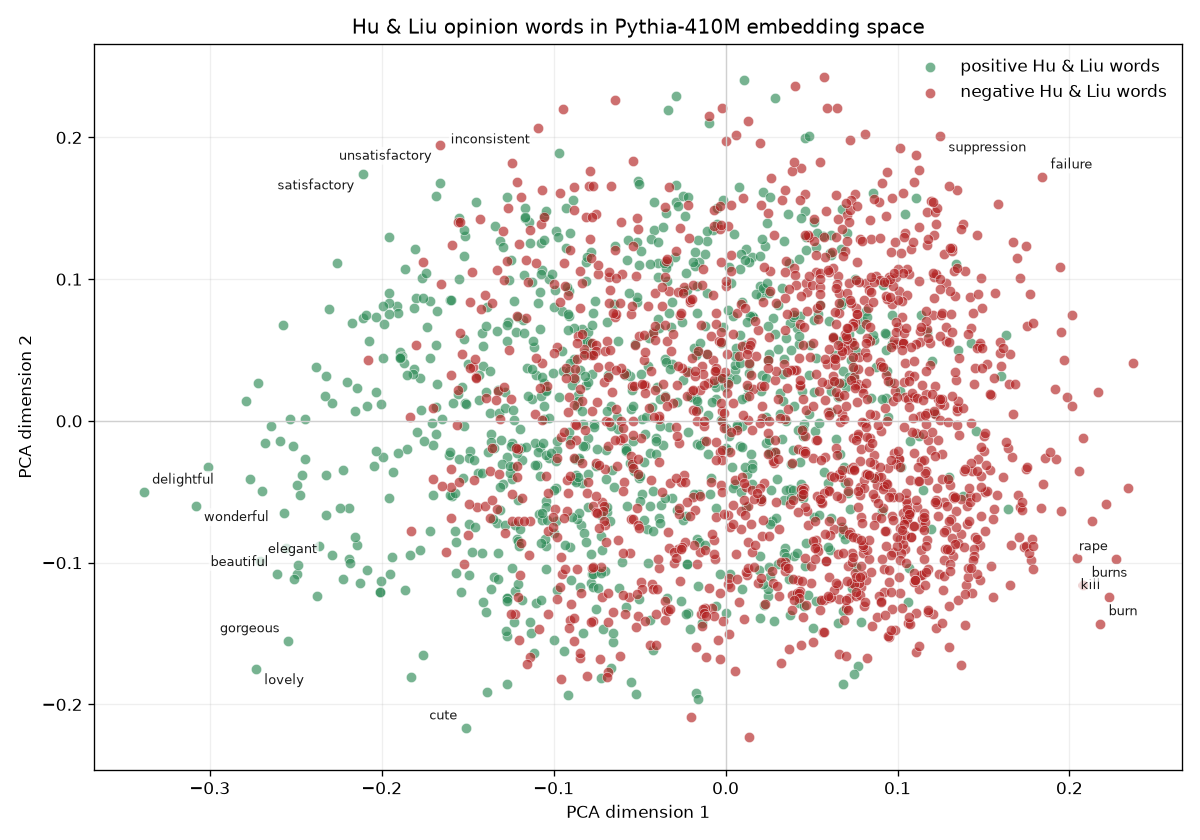

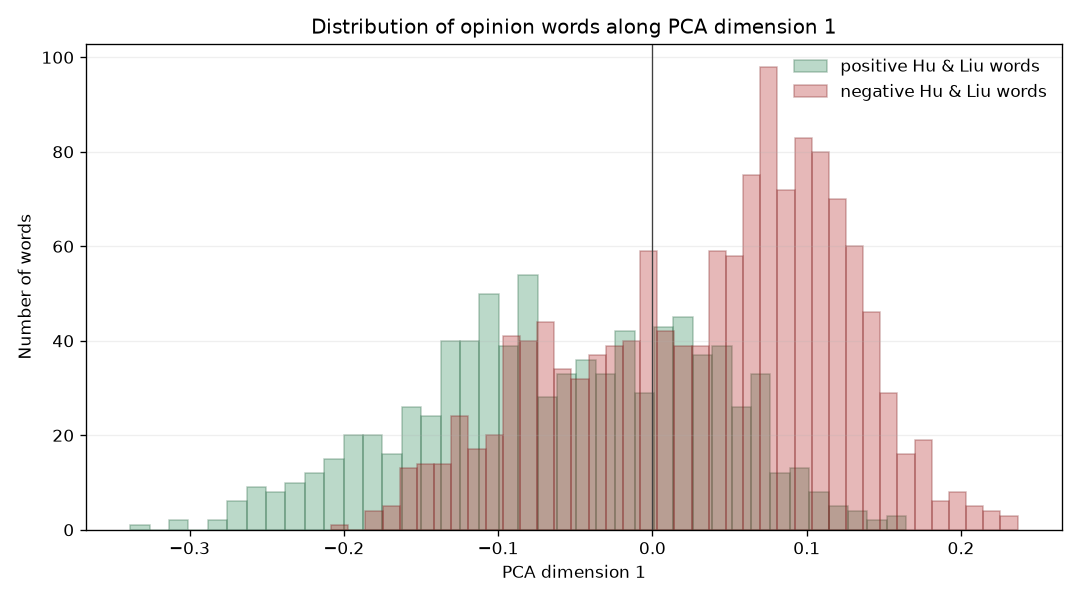

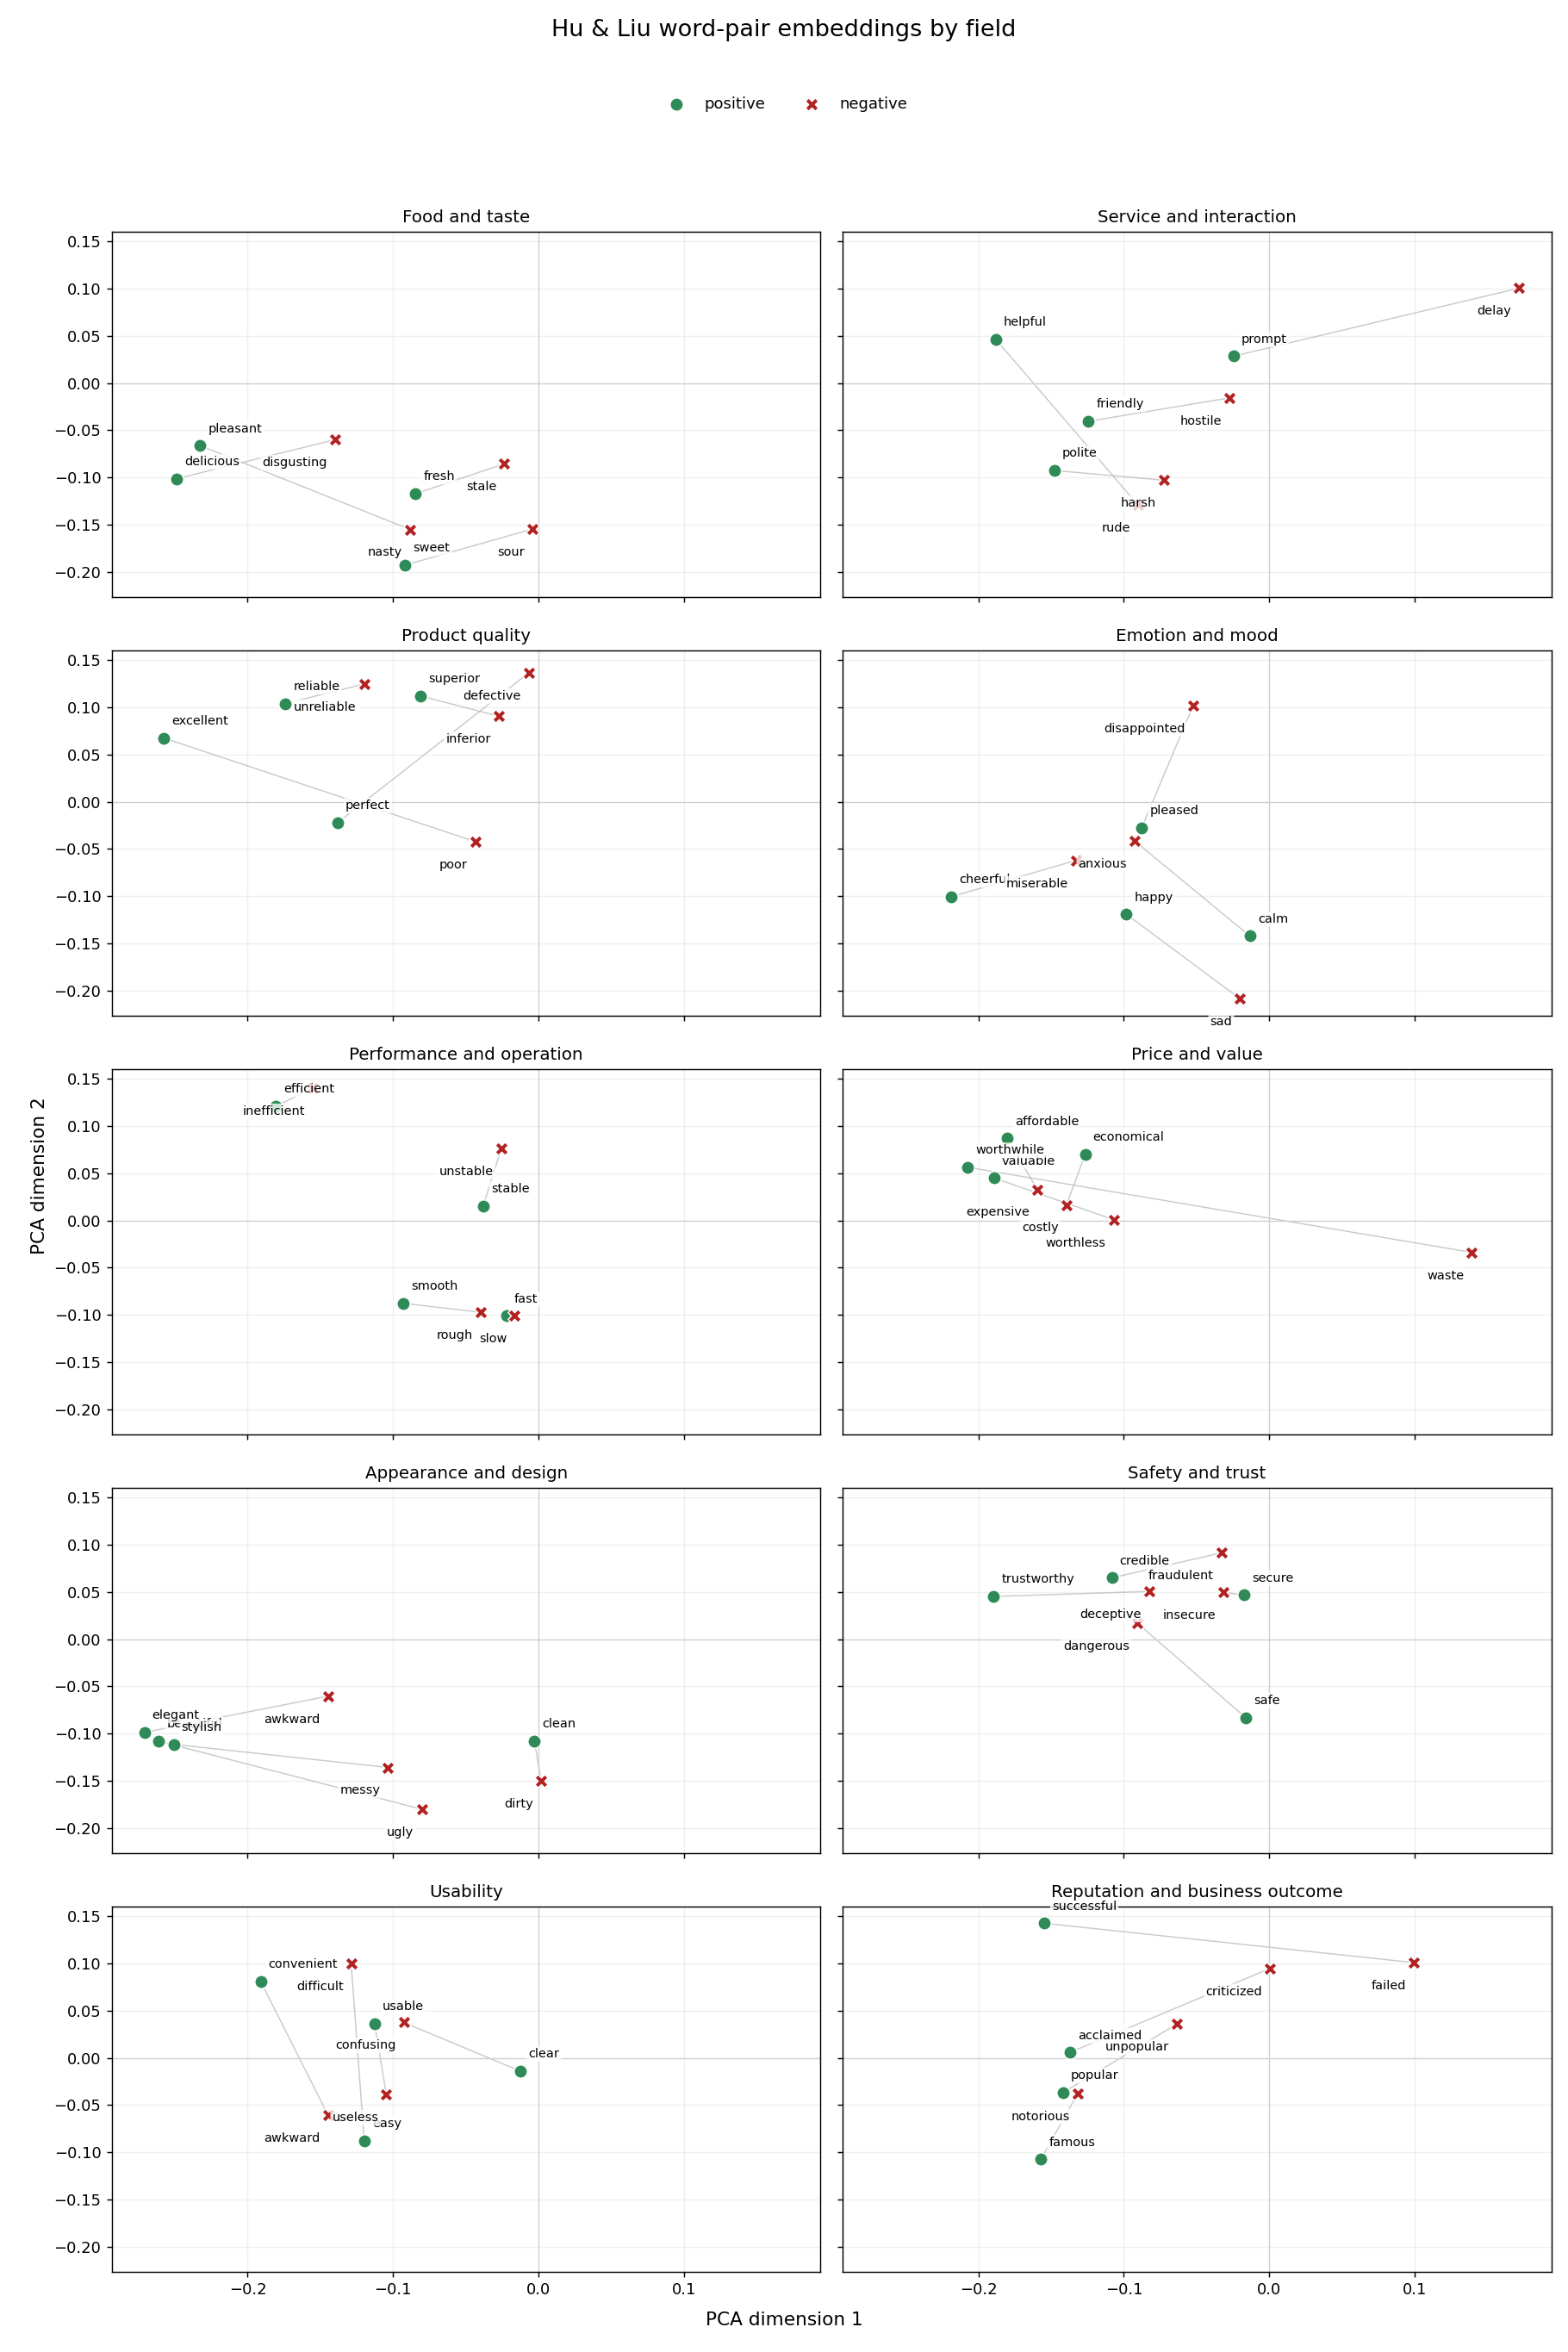

In [71]:
display_image('hu_liu_opinion_embeddings.png')
display_image('hu_liu_opinion_histogram.png')
display_image('hu_liu_field_embedding_panels.png')


### Interpretation der Grafiken

Die Scatterplots reduzieren hochdimensionale Embeddings auf zwei Dimensionen.  
Punkte, die nahe beieinander liegen, haben ähnliche Embedding-Vektoren. Die Farben zeigen, ob ein Wort im Hu-&-Liu-Lexikon positiv oder negativ gelabelt ist.  
Das Histogramm zeigt, ob positive und negative Wörter entlang der ersten PCA-Achse unterschiedlich verteilt sind.


## 7. Token-Embeddings visualisieren

Hier werden weitere Analysen auf den Sentiment-Token-Embeddings durchgeführt: L2-Normen, Cosine-Nachbarn, Embedding-Arithmetik und Projektionen auf eine Sentiment-Richtung.


### 7.1 Normen der Sentiment-Embeddings

Zuerst werden die L2-Normen der Sentiment-Token-Embeddings für alle Felder betrachtet.  
Jedes Feld wird in einer eigenen Box dargestellt, sodass positive und negative Wörter innerhalb desselben Themenbereichs verglichen werden können.


In [72]:
embedding_matrix = sentiment_state["embedding_matrix"]
positive_words = sentiment_state["positive_words"]
negative_words = sentiment_state["negative_words"]

sentiment_embeddings.run_embedding_norm_analysis(embedding_matrix)


Skipping field norm plots: D:\Master\Projects\AI_Frameworks_Tools\assignement\inputs\hu_liu_sentiment_word_pairs_by_field.json not found.


### Ergebnisinterpretation

Die L2-Norm beschreibt die Länge eines Embedding-Vektors.  
Diese Länge ist nicht direkt gleichbedeutend mit Sentiment, kann aber zeigen, ob bestimmte Wörter im Embedding-Raum stärker oder schwächer ausgeprägt sind.


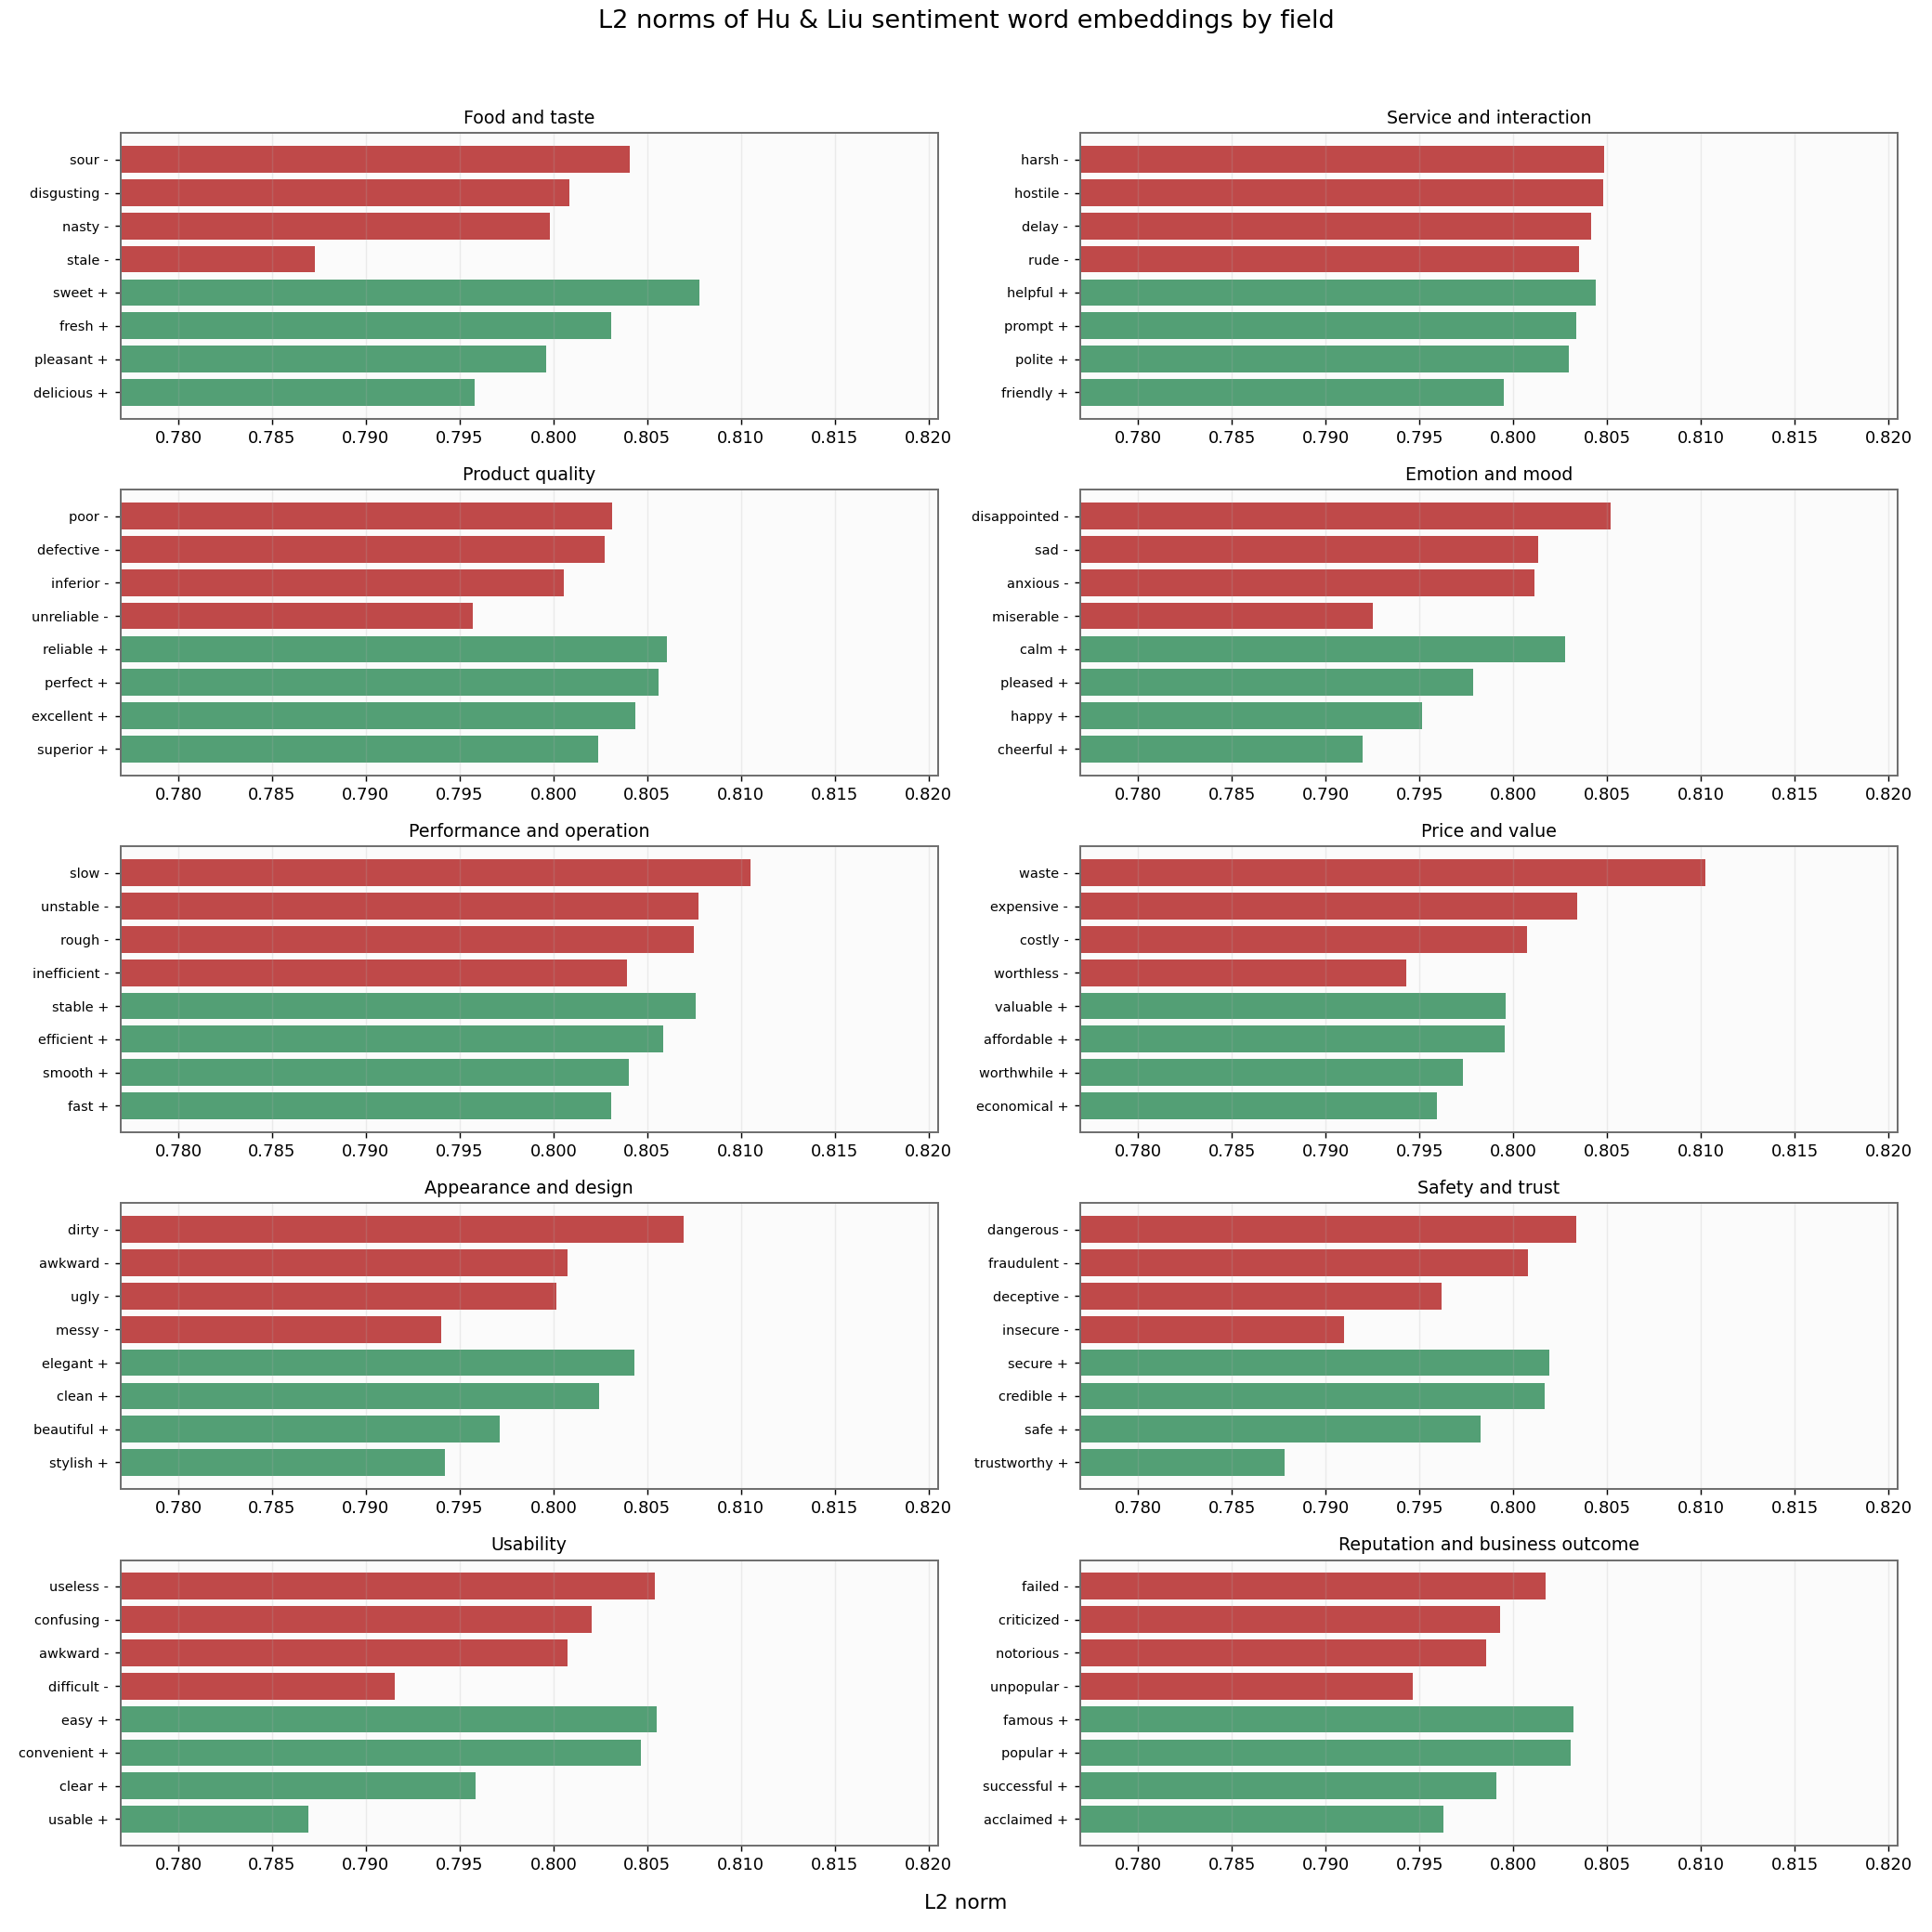

In [73]:
display_image('sentiment_embedding_norms_all_fields.png')


### Interpretation der Norm-Grafiken

Die Balken vergleichen die Embedding-Längen einzelner positiver und negativer Wörter. Jede Box fasst ein Feld zusammen.  
Wenn die Werte sehr nah beieinander liegen, bedeutet das, dass die reine Vektorlänge allein wahrscheinlich kein guter Sentiment-Indikator ist. Interessanter ist dann die Richtung der Vektoren, zum Beispiel über Cosine Similarity oder Projektion.


### 7.2 Cosine-Nachbarn

Für ausgewählte Wörter werden die ähnlichsten Token im gesamten Vokabular und zusätzlich nur innerhalb des Hu-&-Liu-Lexikons gesucht.  
So kann man vergleichen, ob die nächsten Nachbarn semantisch und sentimentbezogen sinnvoll sind.


In [74]:
# Example words to analyze their nearest neighbors in the embedding space.
neighbor_target_words = ["good", "bad", "delicious", "disgusting"]

# Analyze the nearest neighbors of the target words in the embedding space using cosine similarity
# For each word, find the top-k nearest neighbors in general vocabulary and in the Hu Liu dictionary
sentiment_embeddings.run_cosine_neighbor_analysis(
    neighbor_target_words,
    tokenizer,
    embedding_matrix,
    positive_words,
    negative_words,
)


Cosine neighbors for 'good'
----------------------------------------------------------------------------------------
General vocabulary neighbors:
'good'               token_id= 12311 similarity=+0.7330 HuLiu:positive: good
' Good'              token_id=  7088 similarity=+0.6709 HuLiu:positive: good
'Good'               token_id=  8620 similarity=+0.6449 HuLiu:positive: good
' GOOD'              token_id= 29638 similarity=+0.5514 HuLiu:positive: good
' excellent'         token_id=  7126 similarity=+0.4429 HuLiu:positive: excellent

Hu & Liu dictionary neighbors:
excellent            sentiment=positive token_id=  7126 similarity=+0.4429
bad                  sentiment=negative token_id=  3076 similarity=+0.3889
better               sentiment=positive token_id=  1805 similarity=+0.3700
great                sentiment=positive token_id=  1270 similarity=+0.3615
decent               sentiment=positive token_id= 12524 similarity=+0.3506

Cosine neighbors for 'bad'
---------------------------

### Ergebnisinterpretation

Die Analyse der Cosine-Nachbarn zeigt, dass die dem Zielwort im Embedding-Raum am nächsten liegenden Token in den meisten Fällen dieselbe Sentiment-Polarität aufweisen wie das Ausgangswort. Dieses Verhalten konnte sowohl bei der Betrachtung des gesamten Modellvokabulars als auch bei der auf das Hu-&-Liu-Sentiment-Lexikon beschränkten Analyse beobachtet werden. Die Ergebnisse deuten darauf hin, dass sentimentbezogene Informationen bereits im Embedding-Raum kodiert sind und dass semantische Ähnlichkeit häufig mit einer ähnlichen Sentiment-Ausrichtung einhergeht. Positive Wörter besitzen überwiegend positive Nachbarn, während negative Wörter überwiegend von negativen Nachbarn umgeben sind. Diese Konsistenz bestätigt, dass die Embeddings nicht nur semantische Beziehungen, sondern auch sentimentbezogene Eigenschaften der Wörter erfassen.


### 7.3 Embedding-Arithmetik

In diesem Abschnitt werden einfache Rechnungen mit Embedding-Vektoren durchgeführt, zum Beispiel `good + excellent - bad`.  
Das Ergebnis ist kein echtes Token, sondern ein neuer Vektor im Embedding-Raum. Danach wird per Cosine Similarity gesucht, welche existierenden Token diesem Ergebnis am nächsten liegen.

Alle Operanden müssen genau ein Token sein. Wenn ein Wort in mehrere Tokens zerfällt, bricht die Funktion mit einer Fehlermeldung ab.


In [75]:
# Experiment with arithmetic operations on the word embeddings
arithmetic_experiments = [
    "good + excellent - bad",
    "terrible + sad - great",
    "excellent - good",
    "terrible - bad",
    "popular - unpopular",
    "king - man + woman",
    "Paris - France + Germany",
]

# Perform embedding arithmetic analysis on the specified experiments and print the results
sentiment_embeddings.run_embedding_arithmetic_analysis(
    arithmetic_experiments,
    tokenizer,
    embedding_matrix,
    positive_words,
    negative_words,
)



Embedding arithmetic: good + excellent - bad
----------------------------------------------------------------------------------------
' excellent'         token_id=  7126 similarity=+0.7673 HuLiu:positive: excellent
' good'              token_id=  1175 similarity=+0.6207 HuLiu:positive: good
' Excellent'         token_id= 48438 similarity=+0.4961 HuLiu:positive: excellent
'cellent'            token_id= 26128 similarity=+0.4911 
'Excellent'          token_id= 45441 similarity=+0.4538 HuLiu:positive: excellent

Embedding arithmetic: terrible + sad - great
----------------------------------------------------------------------------------------
' sad'               token_id=  8872 similarity=+0.6892 HuLiu:negative: sad
' terrible'          token_id= 11527 similarity=+0.5581 HuLiu:negative: terrible
'Sad'                token_id= 41052 similarity=+0.3597 HuLiu:negative: sad
' horrible'          token_id= 19201 similarity=+0.3532 HuLiu:negative: horrible
' Sad'               token_id= 21995

### Ergebnisinterpretation

Bei der Embedding-Arithmetik werden nicht Token-IDs addiert, sondern Embedding-Vektoren.  
Das Ergebnis ist ein künstlicher Vektor. Die ausgegebenen Tokens sind diejenigen existierenden Vocabulary-Embeddings, die diesem Ergebnisvektor per Cosine Similarity am nächsten liegen. Niedrige maximale Similarity-Werte bedeuten, dass der Ergebnisvektor keinem echten Token sehr nahe kommt.


### 7.4 Sentiment-Richtung

Hier wird eine Sentiment-Richtung mit `embedding("good") - embedding("bad")` gebildet.  
Die Wörter aus den Feldpaaren werden auf diese Richtung projiziert, um zu prüfen, ob positive Wörter tendenziell anders liegen als negative Wörter.


Skipping sentiment direction plot: D:\Master\Projects\AI_Frameworks_Tools\assignement\inputs\hu_liu_sentiment_word_pairs_by_field.json not found.


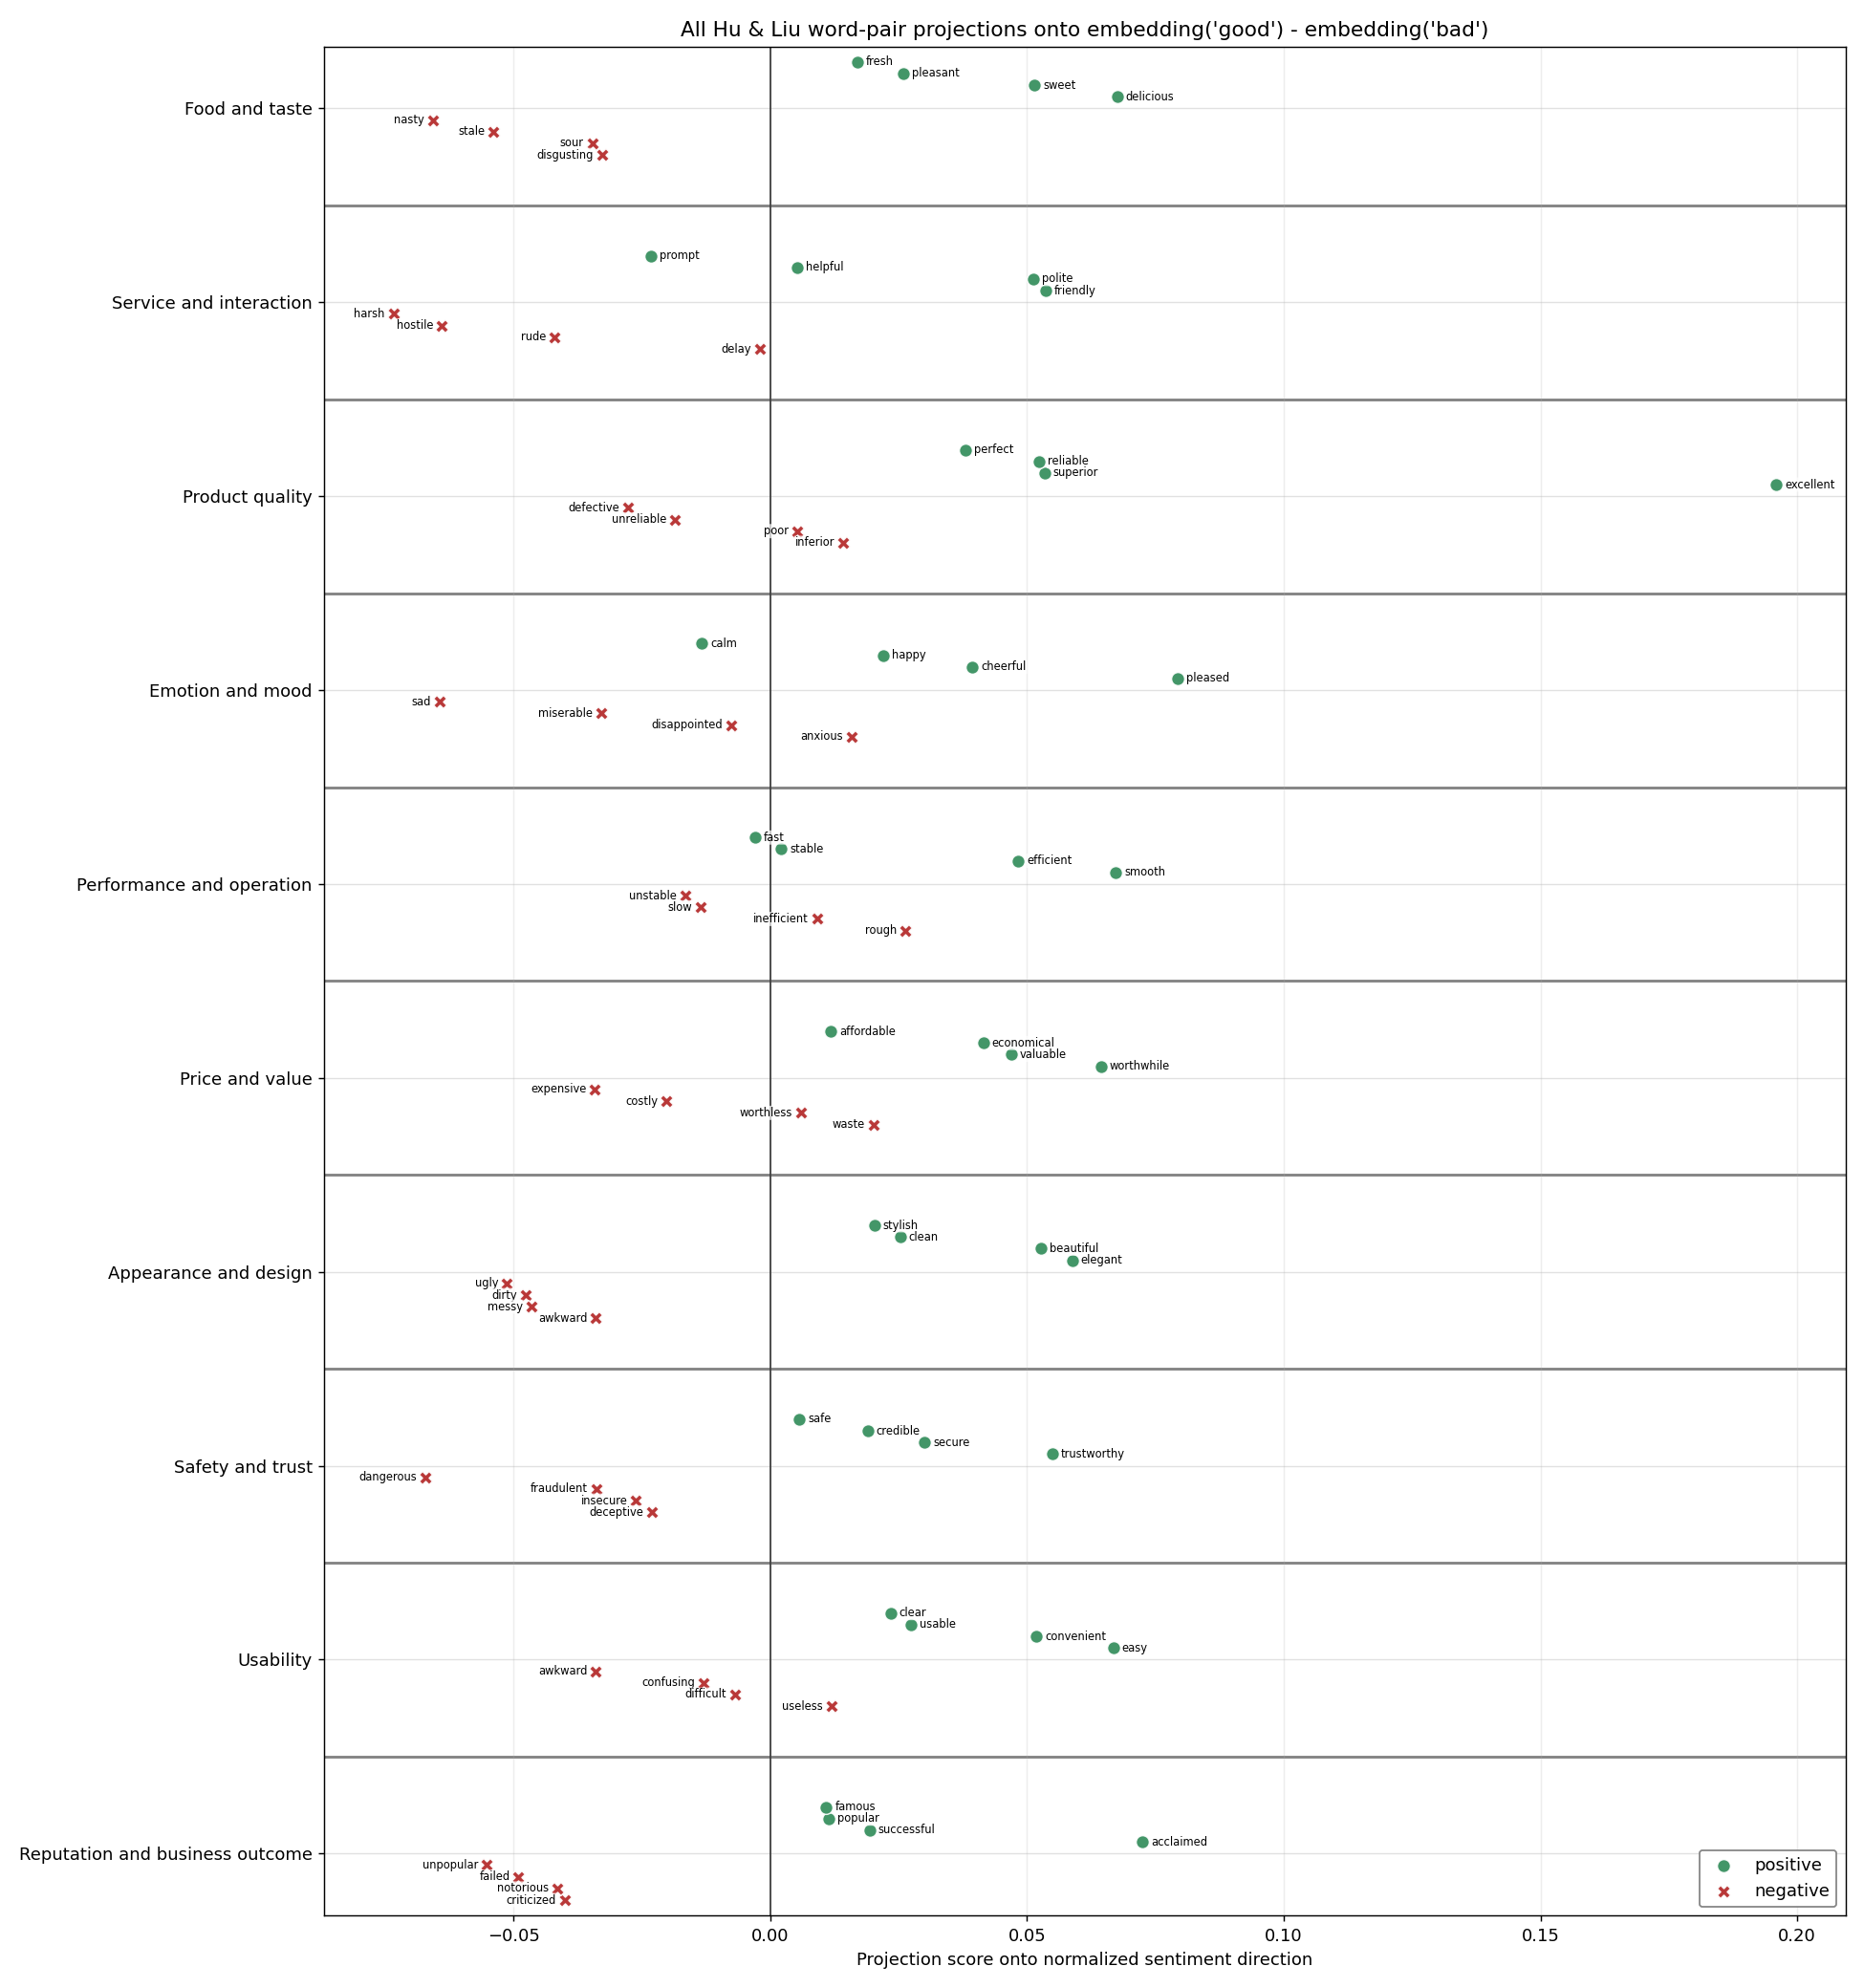

In [76]:
# Project the embeddings onto the sentiment direction defined by the difference between the average positive and negative word embeddings
sentiment_embeddings.run_sentiment_direction_projection(tokenizer, embedding_matrix)

# Visualize the projection of Hi & Liu words of different fields onto the sentiment direction
display_image('sentiment_direction_projection_all_fields.png')

### Ergebnisinterpretation

Die Projektion der Sentiment-Wörter auf die durch den Vektor „good − bad“ definierte Sentiment-Richtung zeigt eine klare Trennung zwischen positiven und negativen Begriffen. Wörter mit positiver Sentiment-Polarität weisen überwiegend positive Projektionswerte auf, während negative Wörter überwiegend negative Werte besitzen. Zudem zeigt sich, dass stärker positiv bzw. stärker negativ konnotierte Begriffe tendenziell weiter von der Mitte entfernt liegen als Wörter mit schwächer ausgeprägtem Sentiment.

Dieses Ergebnis deutet darauf hin, dass ein wesentlicher Teil der Sentiment-Information entlang einer einzelnen linearen Richtung im Embedding-Raum repräsentiert wird. Der Vektor „good − bad“ kann somit als eine Art Sentiment-Achse interpretiert werden, entlang der sich Wörter entsprechend ihrer emotionalen Polarität anordnen. Die beobachtete Struktur bestätigt, dass positive und negative Bedeutungen bereits in den ursprünglichen Token-Embeddings systematisch kodiert sind und durch einfache lineare Projektionen sichtbar gemacht werden können.


## 8. Logistische Regression Sentiment Linear Klassifier

Um zu untersuchen, ob sentimentbezogene Informationen bereits in den ursprünglichen Token-Embeddings des Sprachmodells enthalten sind, wird eine Logistic-Regression-Probe auf den Embeddings trainiert. Dabei dient die Logistic Regression als sogenannter Linear Probe, der überprüft, ob positive und negative Wörter durch eine lineare Entscheidungsgrenze voneinander getrennt werden können.

Als Datengrundlage werden die positiven und negativen Wörter des Hu-&-Liu-Sentiment-Lexikons verwendet. Für jedes Wort wird das entsprechende 1024-dimensionale Embedding aus der Embedding-Schicht des GPT-NeoX-Modells extrahiert. Diese Embeddings bilden die Eingabemerkmale des Klassifikators, während die Sentiment-Polarität (positiv oder negativ) als Zielvariable dient.

Ziel der Analyse ist es nicht, die Qualität eines Sentiment-Klassifikators zu bewerten, sondern zu untersuchen, in welchem Umfang sentimentbezogene Informationen bereits im Embedding-Raum kodiert sind. Eine hohe Klassifikationsgenauigkeit würde darauf hindeuten, dass positive und negative Sentiment-Informationen bereits durch eine einfache lineare Trennung aus den Embeddings extrahiert werden können.



  Kapitel 8: Logistic Regression Sentiment Linear Probe

Loaded fixed logistic-regression split from D:\Master\Projects\AI_Frameworks_Tools\assignement\output\json\hu_liu_logistic_regression_split.json

X.shape = (2254, 1024)
y.shape = (2254,)
Positive labels: 865
Negative labels: 1389
Train examples: 1803
Test examples : 451
Train labels  : positive=692, negative=1111
Test labels   : positive=173, negative=278

--- Logistic Regression Linear Probe Evaluation: test set ---
Accuracy : 0.9690
Precision: 0.9760
Recall   : 0.9422
F1 score : 0.9588

Confusion matrix:
[[274   4]
 [ 10 163]]

Classification report:
              precision    recall  f1-score   support

    negative       0.96      0.99      0.98       278
    positive       0.98      0.94      0.96       173

    accuracy                           0.97       451
   macro avg       0.97      0.96      0.97       451
weighted avg       0.97      0.97      0.97       451


Misclassified test words:
-----------------------------

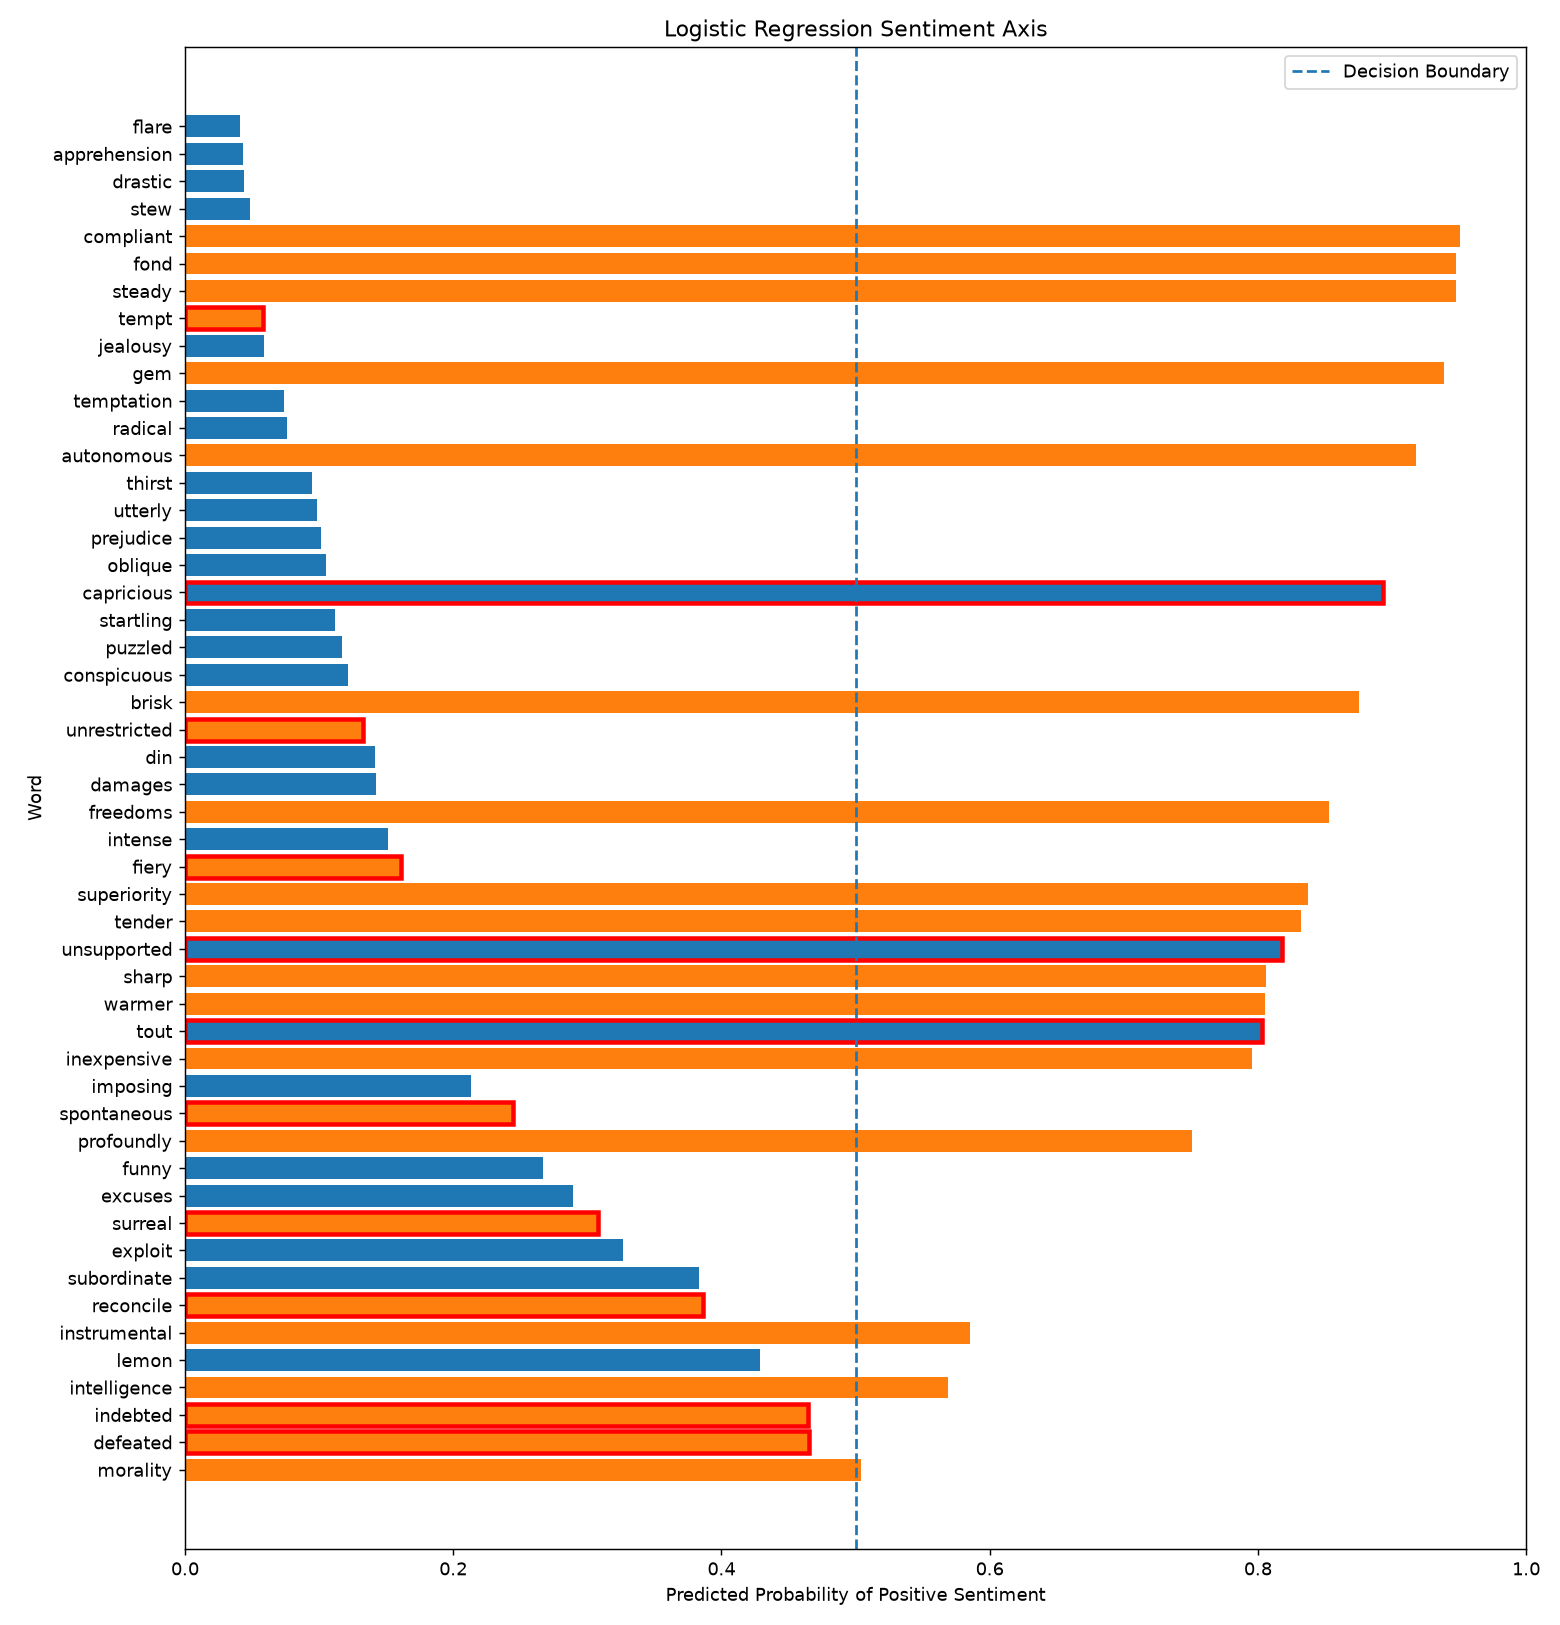

In [77]:
# Train a logistic regression probe to predict the sentiment label (positive vs. negative) from the word embeddings of the Hu & Liu Opinion Lexicon.
classifier, scaler = run_logistic_regression_probe(sentiment_state)

# Visualize the sentiment axis defined by the logistic regression coefficients and the most extreme words on both sides of the axis
display_image('logistic_regression_sentiment_axis.png')

### Ergebnisinterpretation

Die Logistic-Regression-Probe erreichte auf den Embeddings eine Klassifikationsgenauigkeit von 97 % bei gleichzeitig hohen Präzisions-, Recall- und F1-Werten für beide Sentiment-Klassen. Dieses Ergebnis zeigt, dass positive und negative Wörter im Embedding-Raum des Modells weitgehend linear separierbar sind.

Die hohe Genauigkeit deutet darauf hin, dass sentimentbezogene Informationen bereits in den ursprünglichen Token-Repräsentationen kodiert sind und nicht erst durch die nachfolgenden Transformer-Schichten entstehen. Obwohl die PCA-Analyse gezeigt hat, dass die ersten beiden Hauptkomponenten nur einen kleinen Teil der Gesamtvarianz erklären, kann eine einfache lineare Entscheidungsgrenze die Sentiment-Polarität der Wörter dennoch sehr zuverlässig vorhersagen. Dies spricht dafür, dass die Sentiment-Information über viele Dimensionen des Embedding-Raums verteilt ist.

Zusammen mit den Ergebnissen der Cosine-Nachbarschaftsanalyse, der Embedding-Arithmetik und der Sentiment-Projektion entlang der Richtung „good − bad“ liefert die Logistic-Regression-Probe starke Evidenz dafür, dass der Embedding-Raum des Modells bereits eine strukturierte Repräsentation von Sentiment enthält. Positive und negative Bedeutungen sind somit nicht nur semantisch, sondern auch geometrisch im Embedding-Raum organisiert und können durch lineare Methoden erfolgreich voneinander getrennt werden.


## 9. Stanford Sentiment Treebank SST-2

SST-2 ist ein Satz-Level-Datensatz für binäre Sentiment-Analyse.  
Dieses Kapitel lädt den Datensatz, zeigt Splits, Features, Beispielzeilen und Label-Verteilungen.

Für das Projekt ist SST-2 spannend, weil man damit Wort-Level-Sentiment aus Hu & Liu mit Satz-Level-Sentiment vergleichen kann.


In [78]:
run_sst2_inspection()



  Kapitel 9: Stanford Sentiment Treebank SST-2

SST-2 is a sentence-level sentiment dataset. Each example contains a sentence and a binary label: 0 = negative, 1 = positive.

Loaded SST-2 from Hugging Face dataset: nyu-mll/glue

SST-2 splits:
- train      examples=67349
- validation examples=872
- test       examples=1821

SST-2 features:
{'sentence': Value('string'), 'label': ClassLabel(names=['negative', 'positive']), 'idx': Value('int32')}

Example rows from the training split:
label=0 (negative) idx=0      sentence=hide new secretions from the parental units 
label=0 (negative) idx=1      sentence=contains no wit , only labored gags 
label=1 (positive) idx=2      sentence=that loves its characters and communicates something rather beautiful about human nature 
label=0 (negative) idx=3      sentence=remains utterly satisfied to remain the same throughout 
label=0 (negative) idx=4      sentence=on the worst revenge-of-the-nerds clichés the filmmakers could dredge up 
label=0 (negati

### Ergebnisinterpretation

SST-2 enthält vollständige Sätze statt einzelner Wörter.  
Damit eignet sich der Datensatz für einen späteren Vergleich: Hu & Liu prüft Sentiment auf Wortebene, SST-2 prüft Sentiment im Kontext ganzer Sätze. Besonders interessant wären Fälle mit Negation oder gemischtem Sentiment.


## 10. Sentiment Analysis Is Not Solved Challenge Dataset

Dieses Kapitel lädt zuerst den originalen Challenge-Datensatz aus `assignement/inputs/assessing_and_probing_sentiment/annotated.txt` und speichert eine Heatmap der Annotation-Kategorien nach Sentiment-Stufe.

Danach wird der Datensatz für binäre Sentiment-Analyse gefiltert: neutrale Einträge werden entfernt und die verbleibenden Labels werden nur noch als `positive` oder `negative` geführt. Auch dafür wird eine separate Heatmap gespeichert und im Notebook angezeigt.


Saved plot: sentiment_challenge_category_heatmap.png


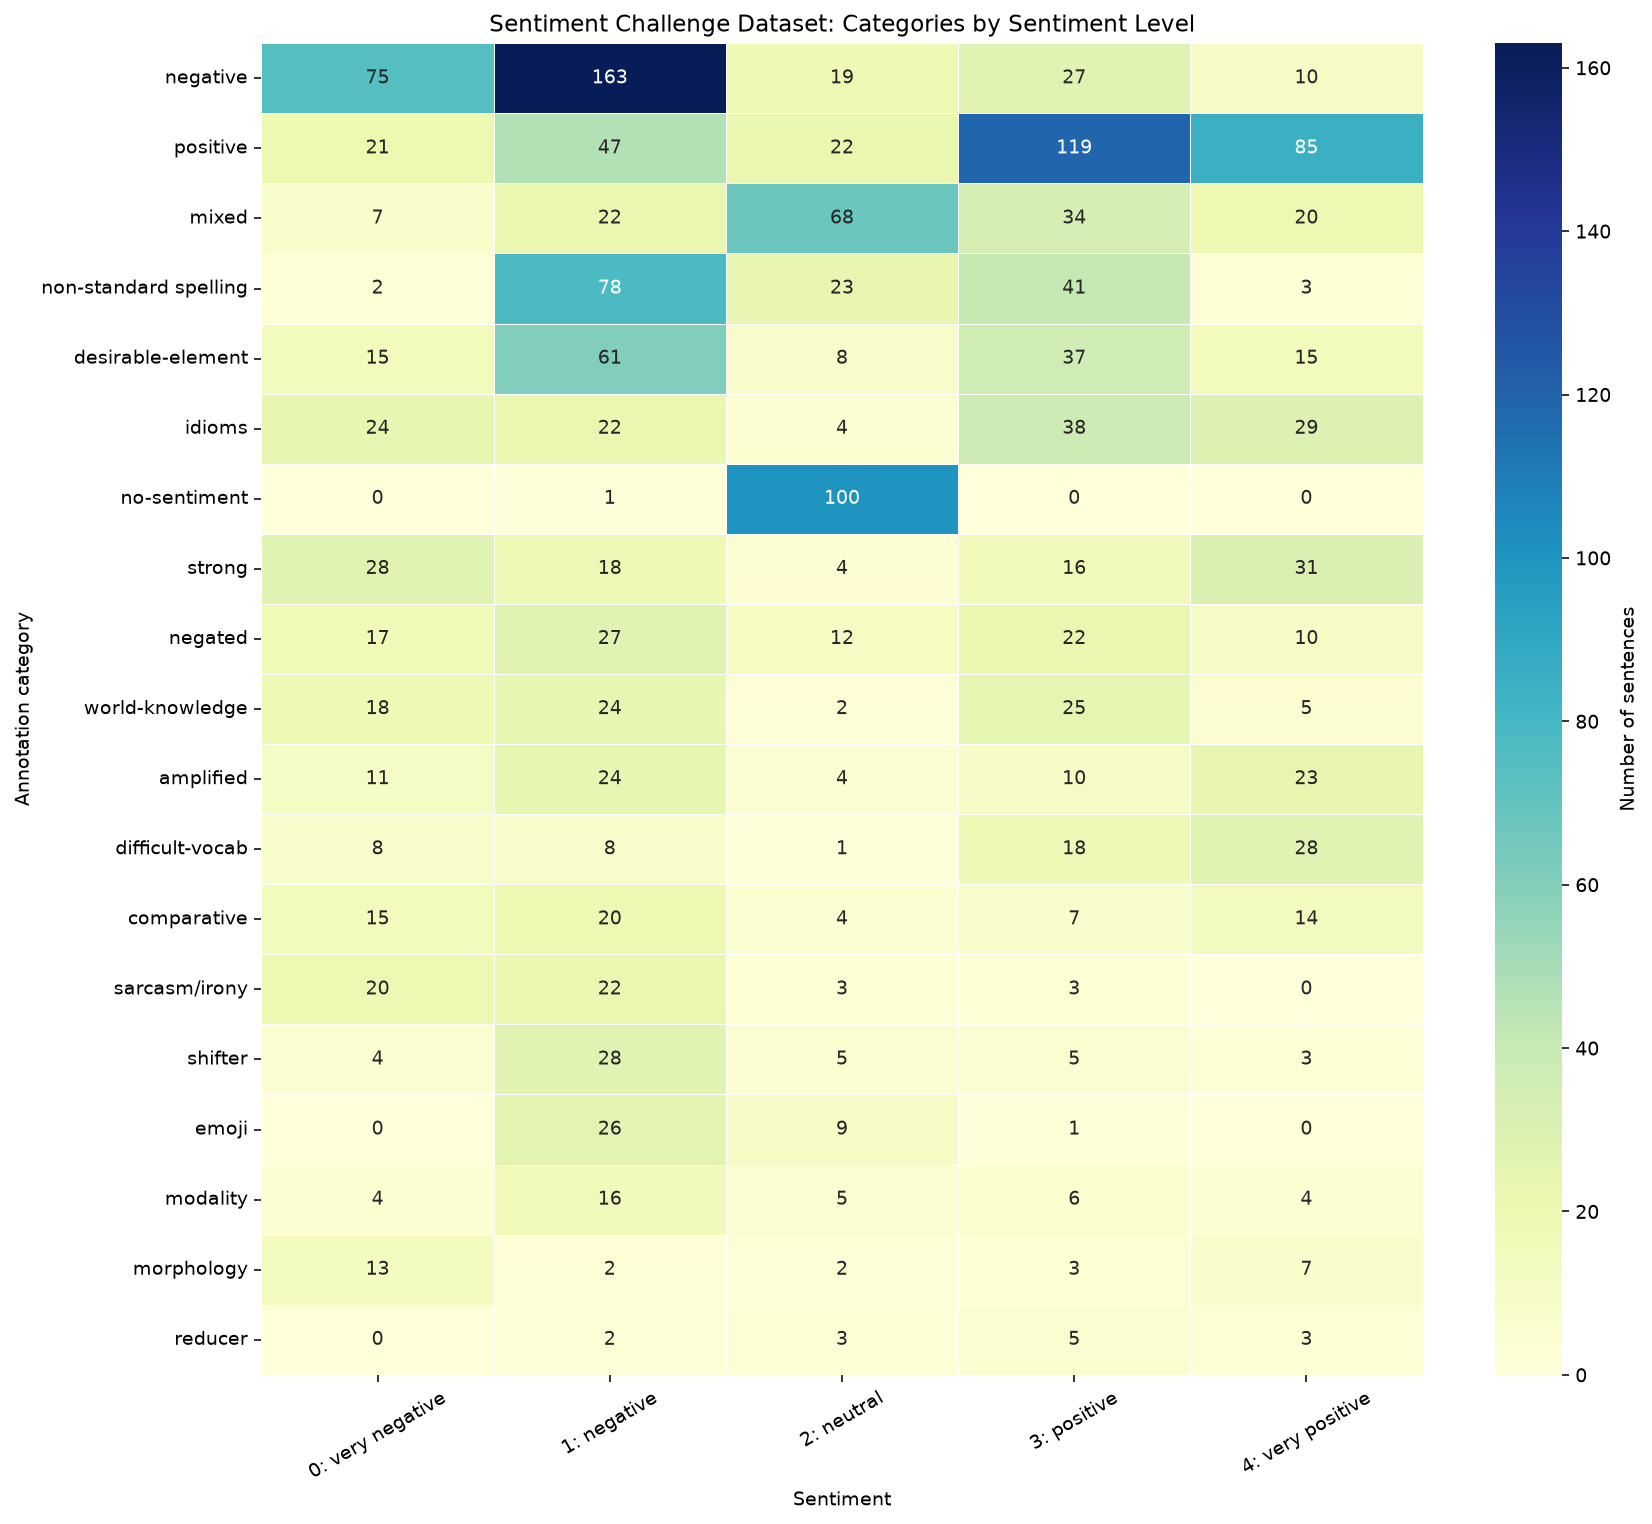

Saved plot: sentiment_challenge_filtered_category_heatmap.png


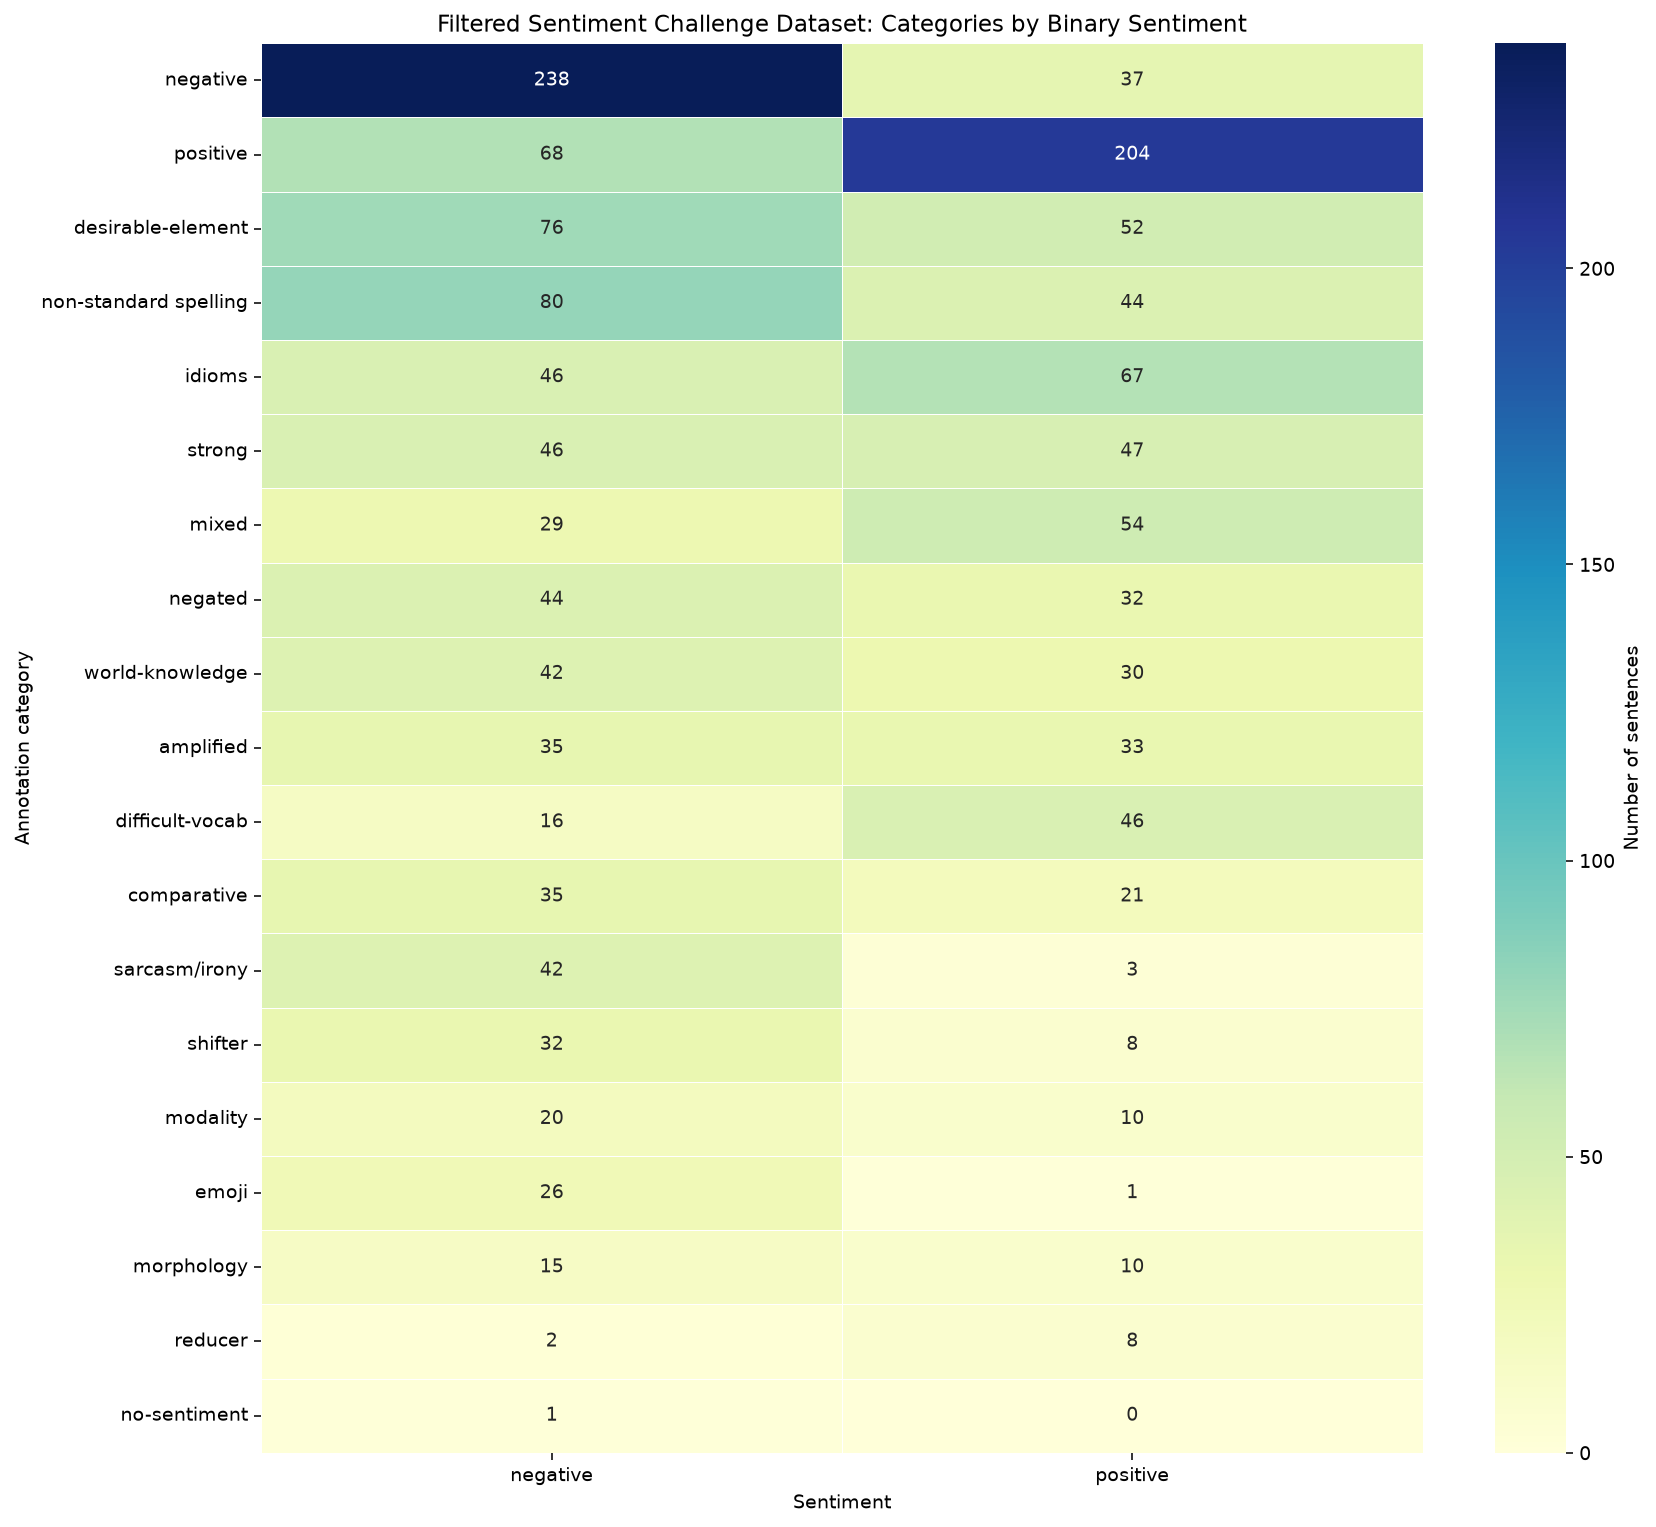

In [84]:
# Import the original sentiment challenge dataset and save its heatmap.
challenge_records, challenge_categories = import_data_set()

# Display the original category-by-sentiment heatmap saved by the utility function.
display_image('sentiment_challenge_category_heatmap.png')

# Filter the challenge dataset by removing neutral examples and converting labels to binary sentiment.
filtered_challenge_records, filtered_challenge_categories = filter_data_set()

# Display the filtered category-by-sentiment heatmap saved by the utility function.
display_image('sentiment_challenge_filtered_category_heatmap.png')


### Top-10 Next-Token Sentiment Probe

Für jeden gefilterten Challenge-Satz wird ein Prompt gebildet, indem der Satz mit ` I feel very` erweitert wird. Danach werden die Top-10 nächsten Tokens des Modells gespeichert. Die Tokens werden mit dem Hu-&-Liu-Lexikon abgeglichen: Wenn mindestens ein Top-10-Token im Lexikon gefunden wird, entscheidet die stärkere positive oder negative Wahrscheinlichkeitsmasse über die Vorhersage. `no sentiment` wird nur verwendet, wenn kein Top-10-Token im Hu-&-Liu-Lexikon gefunden wird.


Top-token prompt details were saved to:
- D:\Master\Projects\AI_Frameworks_Tools\assignement\output\sentiment_challenge_prompt_top10_tokens_report.txt
- D:\Master\Projects\AI_Frameworks_Tools\assignement\output\json\sentiment_challenge_prompt_top10_tokens.json
Saved plot: sentiment_challenge_category_confusion_matrices.png
Saved plot: sentiment_challenge_category_accuracy.png


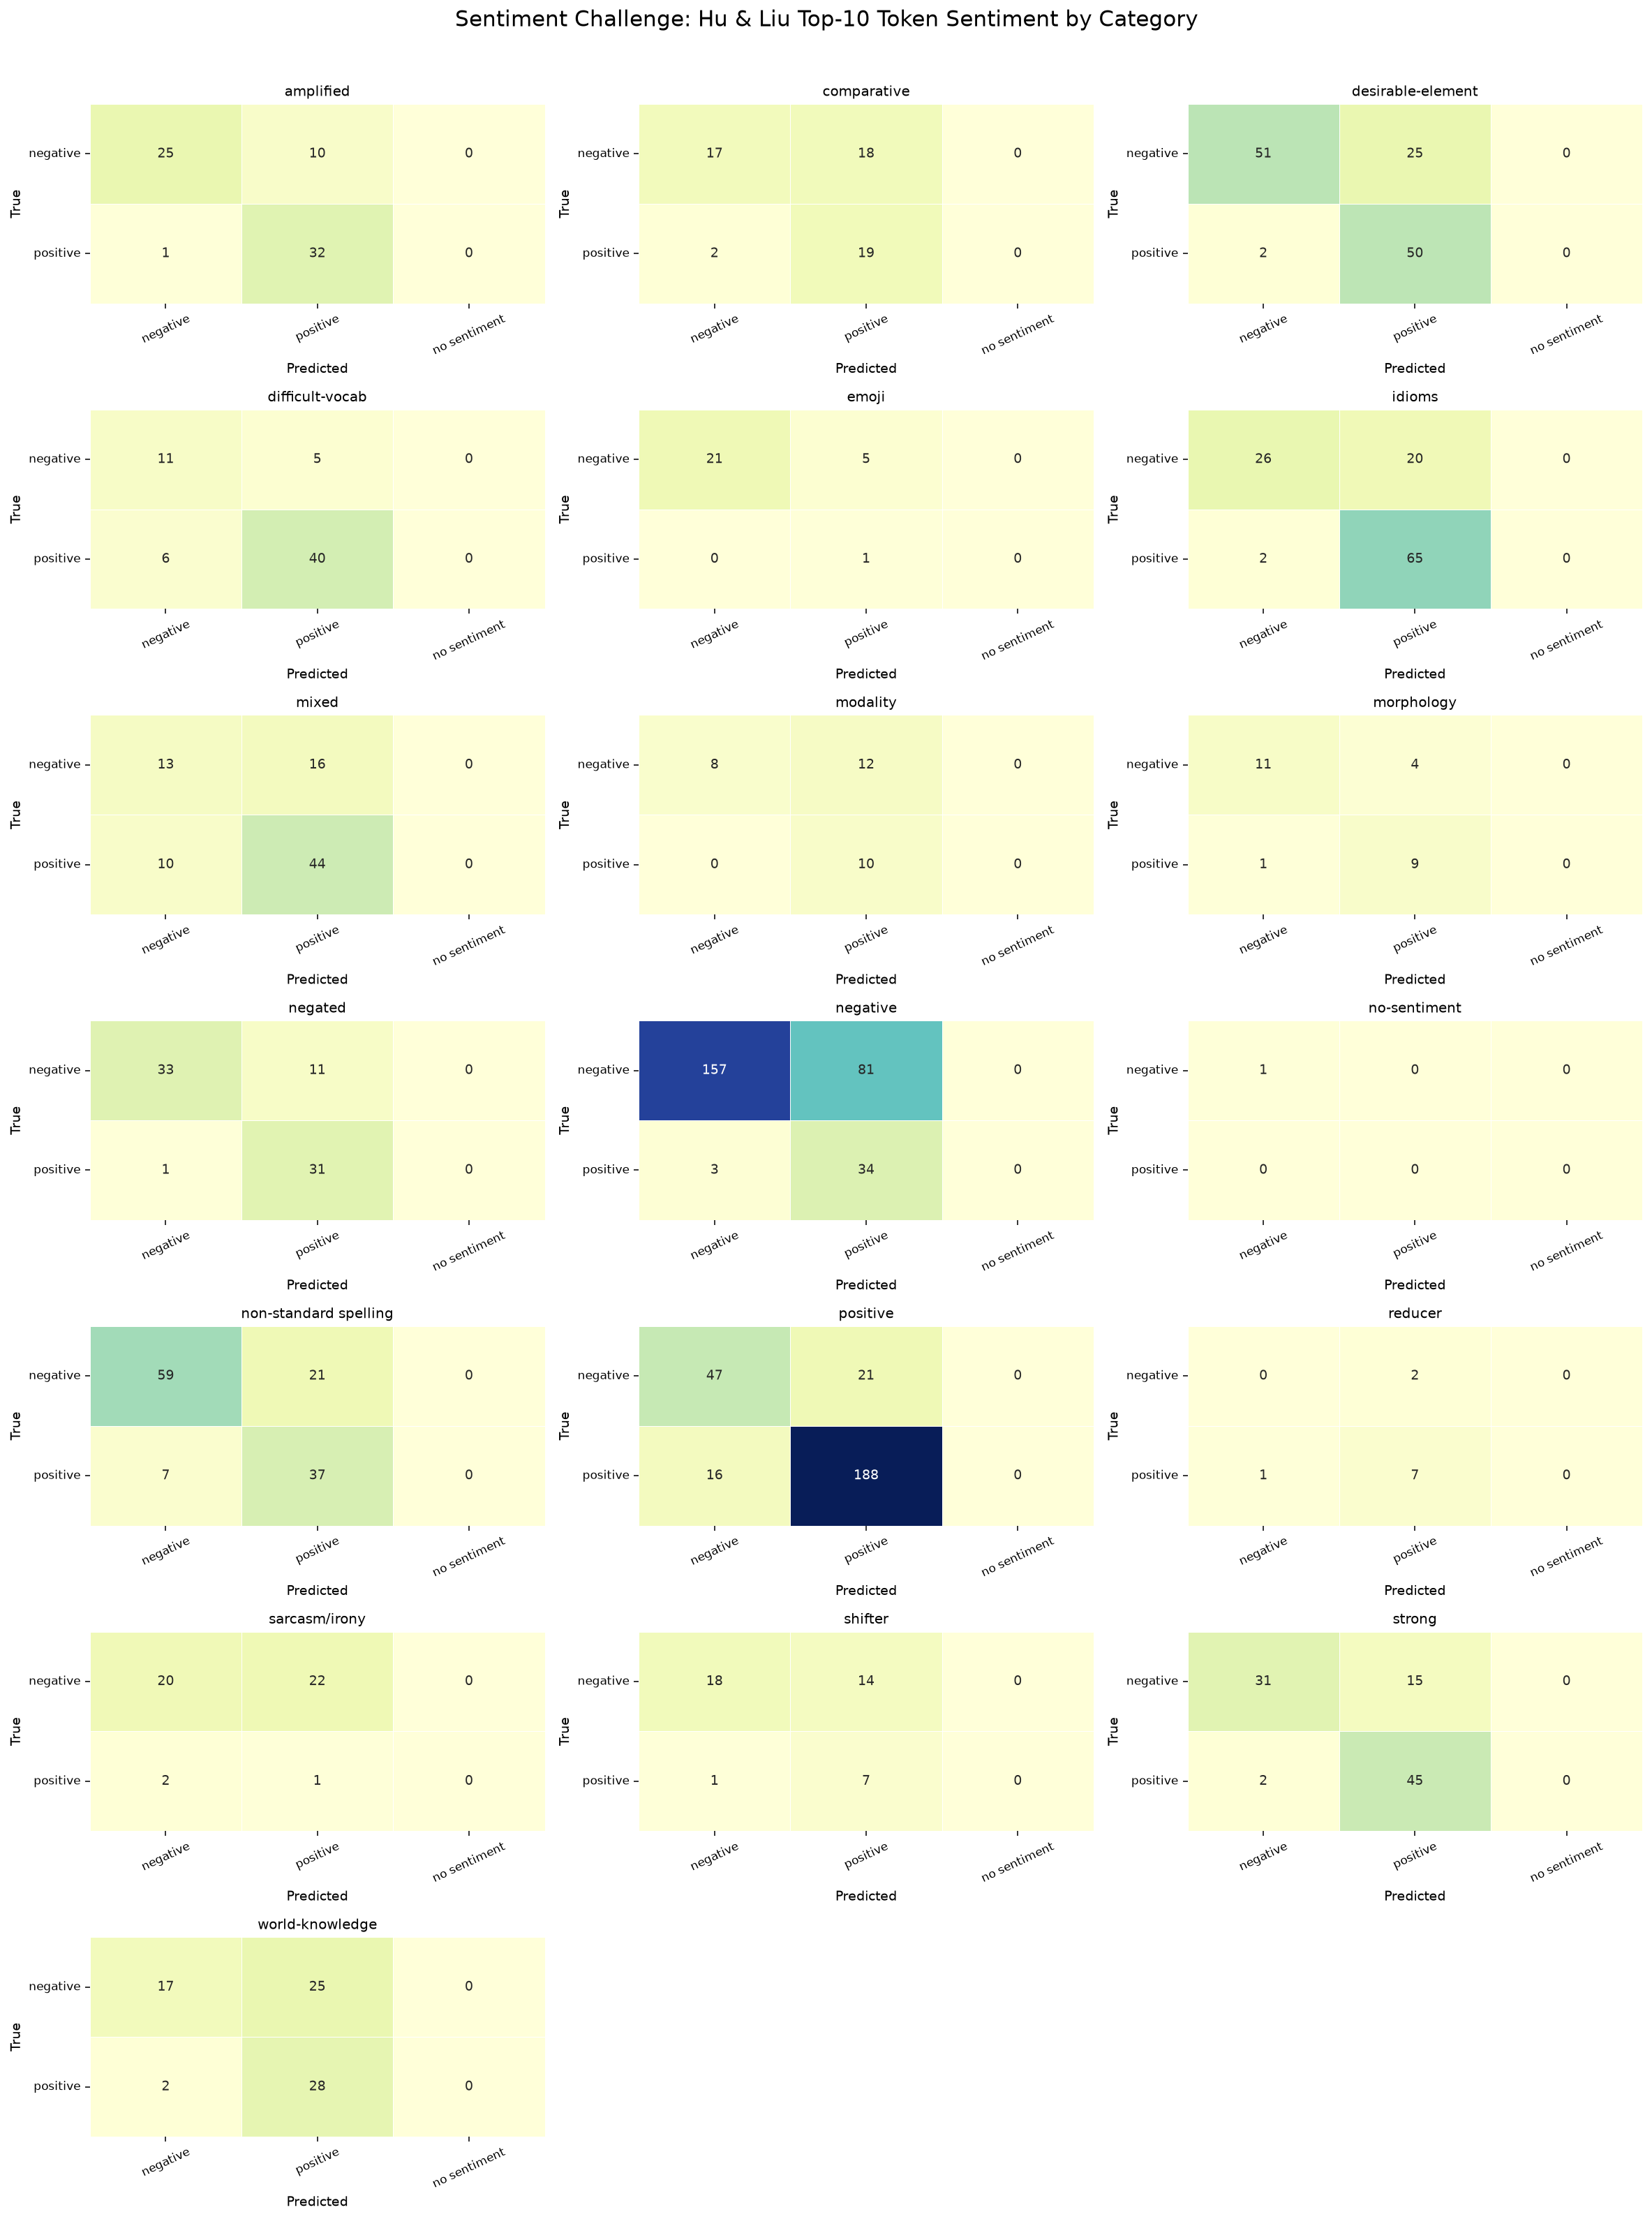

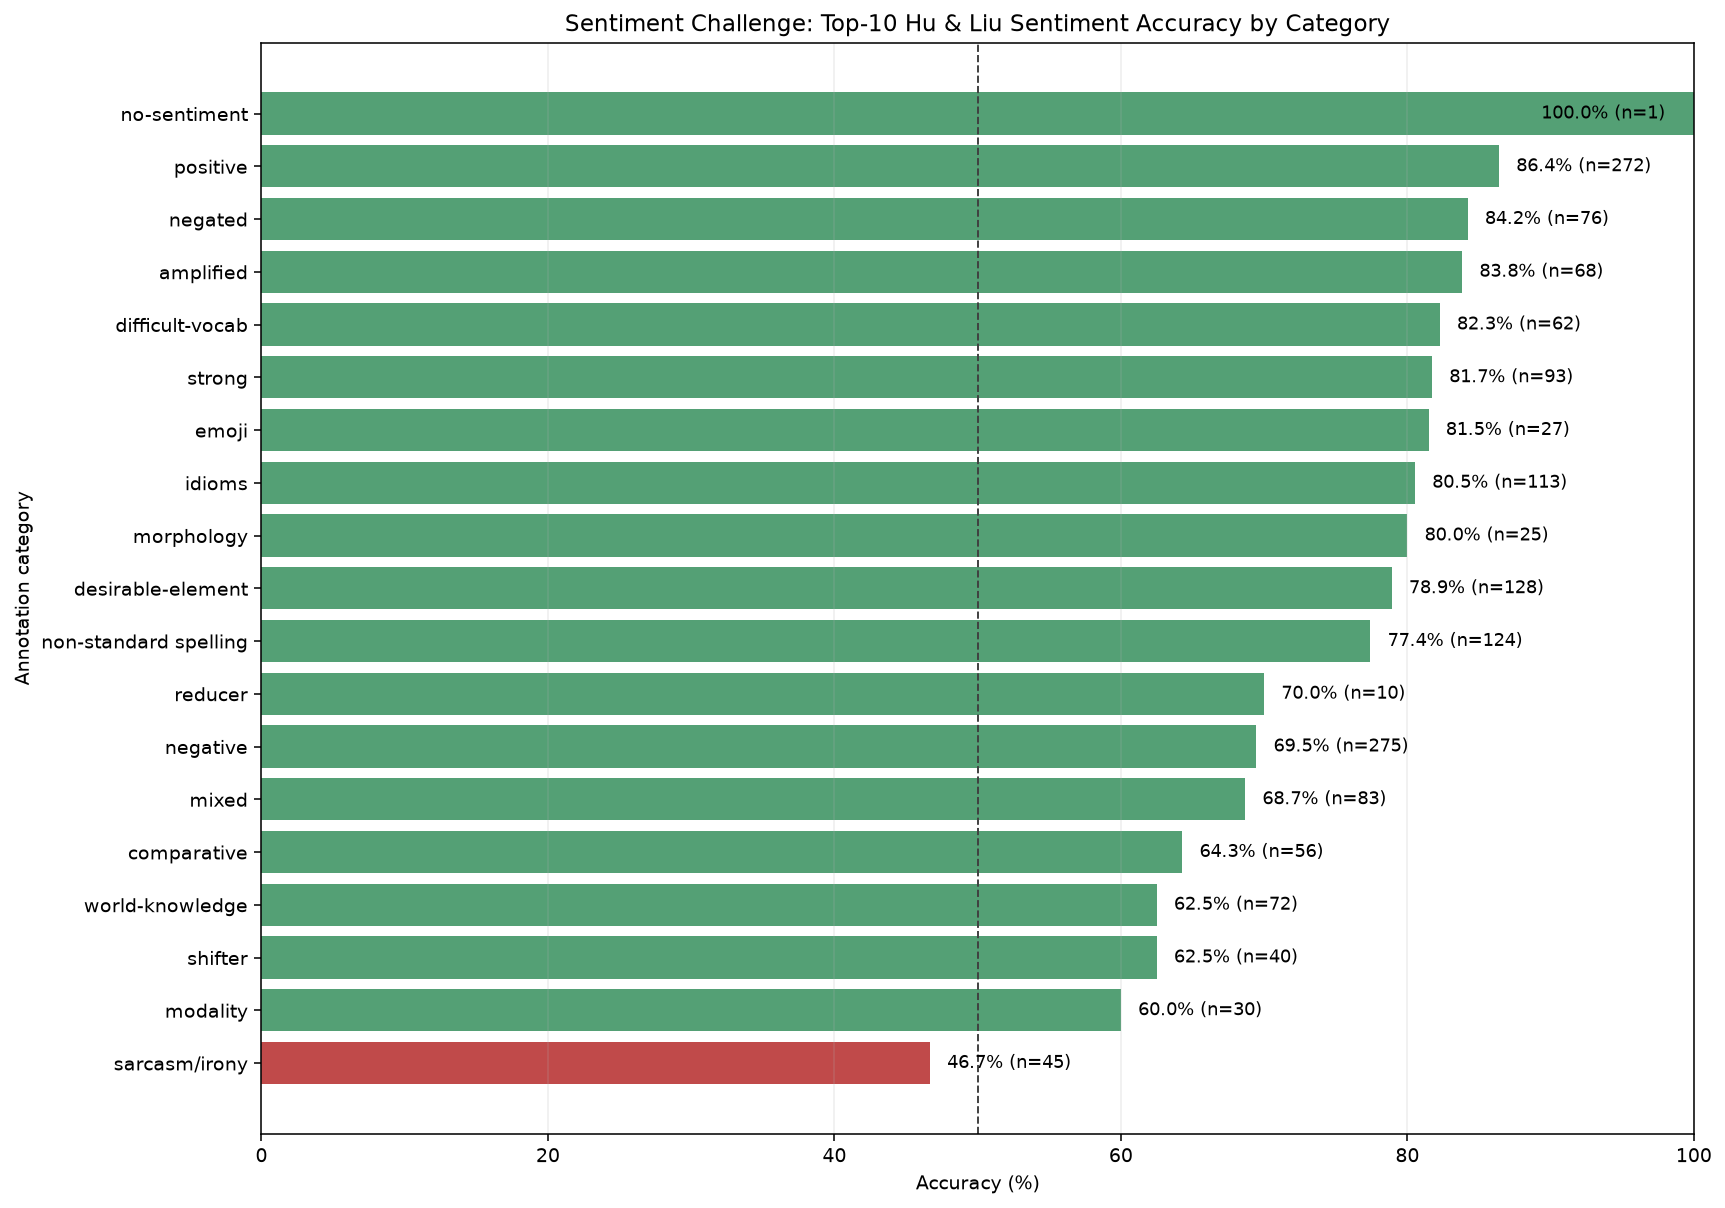

In [85]:
# Define the suffix that is appended to every filtered challenge sentence.
sentiment_suffix = " I feel very"

# Build one prompt per filtered dataset entry.
prompt_records = form_sentiment_challenge_prompts(
    filtered_challenge_records,
    sentiment_suffix,
)

# Run the model, save the top-10 next-token predictions, and build category-level metrics.
challenge_prediction_results, category_confusion_counts, category_accuracy_rows = (
    run_sentiment_challenge_top_token_analysis(
        model,
        tokenizer,
        device,
        prompt_records,
        positive_words,
        negative_words,
        top_k=10,
        batch_size=8,
    )
)

# Display the saved confusion-matrix and category-accuracy plots.
display_image('sentiment_challenge_category_confusion_matrices.png')
display_image('sentiment_challenge_category_accuracy.png')


### Ergebnisinterpretation

Nach dem Entfernen der neutralen Beispiele bleiben 636 Sätze übrig. Davon sind 353 negativ und 283 positiv gelabelt. Die Top-10-Token-Analyse erreicht insgesamt 478 korrekte Vorhersagen, also etwa 75,2 % Accuracy. Das Modell sagt dabei häufiger `positive` als `negative` voraus (393 positive gegenüber 243 negative Vorhersagen). In der gespeicherten Ausgabe wurde für jeden Prompt mindestens ein Hu-&-Liu-Treffer unter den Top-10-Tokens gefunden; deshalb tritt `no sentiment` in diesem Lauf nicht als Vorhersage auf.

Die Genauigkeit unterscheidet sich deutlich zwischen den Kategorien. Besonders gut funktionieren Kategorien wie `positive` (86,4 %), `negated` (84,2 %), `amplified` (83,8 %) und `difficult-vocab` (82,3 %). Schwieriger sind dagegen `sarcasm/irony` (46,7 %), `modality` (60,0 %), `world-knowledge` (62,5 %) und `shifter` (62,5 %). Das passt zur Erwartung: Ein lexikonbasierter Blick auf die nächsten Tokens erkennt einfache positive oder negative Signalwörter relativ gut, ist aber schwächer bei Kategorien, die Kontext, Weltwissen, Ironie oder pragmatische Bedeutungsverschiebungen erfordern.

Die wichtigste Schlussfolgerung ist daher, dass das Modell im nächsten Token oft sentimentnahe Wörter produziert, diese Methode aber kein vollständiger Satzklassifikator ist. Sie misst eher, ob die direkte Fortsetzung des Prompts ein Hu-&-Liu-Sentimentwort bevorzugt. Für robuste Sentiment-Klassifikation auf schwierigen Challenge-Beispielen reicht ein einfacher Lexikonabgleich der Top-10-Tokens nicht aus.


## 11. Zusammenfassung

In diesem Notebook wurde untersucht, ob Sentiment-Informationen bereits im Input-Embedding-Raum von `EleutherAI/pythia-410m` sichtbar sind.

Pythia-410M ist ein Decoder-Only-Transformer auf Basis der GPT-NeoX-Architektur. Jedes Eingabetoken wird durch einen 1024-dimensionalen Embedding-Vektor repräsentiert. Die Parameteranalyse zeigt, dass der größte Anteil der Parameter in den Transformer-Schichten liegt, besonders in den MLP-Blöcken. Embedding- und Unembedding-Matrizen sind ebenfalls zentrale Komponenten, weil sie die Verbindung zwischen Tokens und Vektoren herstellen.

Die Top-K-Vorhersagen zeigen, dass das Modell einfachen Sentiment-Kontext erkennt. Positive Prompts führen eher zu positiven Fortsetzungen wie `excellent`, `great` oder `good`, während negative Prompts eher Wörter wie `terrible`, `awful` oder `horrible` erzeugen. Das ist ein erster Hinweis darauf, dass Sentiment-Muster im Modellverhalten vorhanden sind.

Für die Embedding-Analyse wurde das Hu-&-Liu-Opinion-Lexikon verwendet. Die Wörter wurden so gefiltert, dass nur einfache alphabetische Wörter übrig bleiben, die vom Pythia-Tokenizer als genau ein Token dargestellt werden. Dadurch kann jedes Wort eindeutig einem einzelnen Input-Embedding zugeordnet werden.

Die PCA-Visualisierungen zeigen keine perfekte Trennung zwischen positiven und negativen Wörtern. Trotzdem sind räumliche Tendenzen sichtbar. Die Überlappung zeigt, dass Sentiment nicht vollständig durch zwei reduzierte Dimensionen beschrieben werden kann.

Die Analyse der L2-Normen zeigt, dass die reine Länge eines Embedding-Vektors kein zuverlässiger Sentiment-Indikator ist. Positive und negative Wörter können ähnliche Normen besitzen. Aussagekräftiger sind daher Richtungen und Nachbarschaften im Vektorraum.

Die Cosine-Nachbarn zeigen, dass semantisch ähnliche Wörter häufig auch eine ähnliche Sentiment-Polarität besitzen. Das spricht dafür, dass der Embedding-Raum nicht nur Bedeutung, sondern auch sentimentbezogene Eigenschaften kodiert.

Die Embedding-Arithmetik auf Embedding Vektoren hat gezeigt, dass sentimentbezogene Beziehungen durch einfache Vektoroperationen nachvollzogen werden können. Kombinationen wie „stark positiv − schwach negativ“ führten weiterhin zu überwiegend positiven Repräsentationen.

Der Vektor `good − bad` kann somit als eine Art Sentiment-Achse interpretiert werden, entlang der sich Wörter entsprechend ihrer emotionalen Polarität anordnen.

Den stärksten quantitativen Hinweis auf die Kodierung von Sentiment lieferte die Logistic-Regression-Probe. Die Klassifikation der Hu-&-Liu-Sentiment-Wörter erreichte eine Genauigkeit von 97 % bei gleichzeitig hohen Präzisions-, Recall- und F1-Werten. Dies zeigt, dass positive und negative Wörter bereits im ursprünglichen Embedding-Raum weitgehend linear separierbar sind. Die hohe Leistung einer einfachen linearen Entscheidungsgrenze deutet darauf hin, dass sentimentbezogene Informationen nicht erst in den Transformer-Schichten entstehen, sondern bereits in den Token-Repräsentationen enthalten sind.

SST-2 wurde zusätzlich betrachtet, weil dieser Datensatz Sentiment auf Satzebene enthält. Dadurch eignet er sich als möglicher nächster Schritt, um Wort-Level-Sentiment aus Hu & Liu mit Satz-Level-Sentiment im Kontext vollständiger Sätze zu vergleichen.

Insgesamt zeigen die Ergebnisse aller durchgeführten Analysen ein konsistentes Bild. Die Embeddings des Modells enthalten bereits vor der eigentlichen Transformer-Verarbeitung eine strukturierte Repräsentation von Sentiment. Diese Struktur äußert sich in sentimenthomogenen Nachbarschaften, sinnvollen Ergebnissen der Embedding-Arithmetik, einer klar erkennbaren Sentiment-Achse sowie einer hohen linearen Separierbarkeit positiver und negativer Wörter. Die Untersuchung liefert damit Evidenz dafür, dass sentimentbezogene Informationen bereits auf Ebene der Token-Embeddings kodiert werden und eine wichtige Grundlage für die weitere Verarbeitung durch die nachfolgenden Transformer-Schichten bilden.


Zusätzlich wurde der Challenge-Datensatz *Sentiment Analysis Is Not Solved!* eingebunden. Er zeigt schwierige Fehlerkategorien wie Negation, Ironie, Idiome, Emoji, gemischtes Sentiment und schwieriges Vokabular. Dadurch kann die Modellinspektion später gezielt auf Fälle erweitert werden, in denen einfache Sentiment-Signale nicht ausreichen.